# **Relaciones Stocks**

In [ ]:
###########################################################
# Librerias
###########################################################
import pandas as pd
import dcor
import numpy as np
import yfinance as yf
from dtaidistance import dtw
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from statsmodels.tsa.stattools import coint, grangercausalitytests
from scipy import signal
import dcor
from datetime import datetime, timedelta
import networkx as nx
from scipy import stats
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

In [12]:
# ============================================
# 1. DESCARGA Y PREPARACIÓN DE DATOS
# ============================================

# Los 7 magníficos
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA']
nombres = {
    'AAPL': 'Apple',
    'MSFT': 'Microsoft', 
    'GOOGL': 'Alphabet (Google)',
    'AMZN': 'Amazon',
    'META': 'Meta',
    'NVDA': 'NVIDIA',
    'TSLA': 'Tesla'
}

# Descarga 2 años de datos
end_date = datetime.now()
start_date = end_date - timedelta(days=730)

print("Descargando datos de los 7 Magníficos...")
data = yf.download(tickers, start=start_date, end=end_date, progress=False)

# Extraemos Close y Volume
close_data = data['Close'].dropna()
volume_data = data['Volume'].dropna()

# También descargo SPY y QQQ para comparación
benchmarks = yf.download(['SPY', 'QQQ'], start=start_date, end=end_date, progress=False)['Close']

print(f"Datos descargados: {close_data.shape[0]} días de trading")
print(f"Tickers: {close_data.columns.tolist()}")

Descargando datos de los 7 Magníficos...
Datos descargados: 501 días de trading
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']


##############################################################################################
## **METODO 1: CORRELACIÓN DE PEARSON**
##############################################################################################

* Qué detecta: Relación lineal contemporánea
* Limitación: No detecta relaciones no lineales ni rezagadas

In [26]:
returns=close_data.pct_change().dropna()
returns_log=np.log(close_data / close_data.shift(1)).dropna()

In [29]:
def pearson_analysis(returns):
    """Correlación Pearson + p-values limpios"""
    corr_matrix = returns.corr()

    # matriz vacía para p-values
    p_values = pd.DataFrame(
        np.zeros_like(corr_matrix),
        index=corr_matrix.index,
        columns=corr_matrix.columns
    )

    for i in corr_matrix.index:
        for j in corr_matrix.columns:
            if i!= j:
                _, p = stats.pearsonr(returns[i].dropna(), returns[j].dropna())
                p_values.loc[i, j] = p
            else:
                p_values.loc[i, j] = 0.0 # diagonal, no se testea

    return corr_matrix, p_values

# lo usas igual que antes
pearson_corr, pearson_pvals = pearson_analysis(returns_log)

# comprobación rápida
print(pearson_corr.round(2))
print("\nSignificativos (p<0.05):")
print((pearson_pvals < 0.05) & (pearson_pvals > 0))

Ticker  AAPL  AMZN  GOOGL  META  MSFT  NVDA  TSLA
Ticker                                           
AAPL    1.00  0.48   0.43  0.42  0.38  0.37  0.44
AMZN    0.48  1.00   0.55  0.60  0.52  0.47  0.47
GOOGL   0.43  0.55   1.00  0.43  0.36  0.41  0.47
META    0.42  0.60   0.43  1.00  0.49  0.47  0.42
MSFT    0.38  0.52   0.36  0.49  1.00  0.50  0.38
NVDA    0.37  0.47   0.41  0.47  0.50  1.00  0.47
TSLA    0.44  0.47   0.47  0.42  0.38  0.47  1.00

Significativos (p<0.05):
Ticker   AAPL   AMZN  GOOGL   META   MSFT   NVDA   TSLA
Ticker                                                 
AAPL    False   True   True   True   True   True   True
AMZN     True  False   True   True   True   True   True
GOOGL    True   True  False   True   True   True   True
META     True   True   True  False   True   True   True
MSFT     True   True   True   True  False   True   True
NVDA     True   True   True   True   True  False   True
TSLA     True   True   True   True   True   True  False


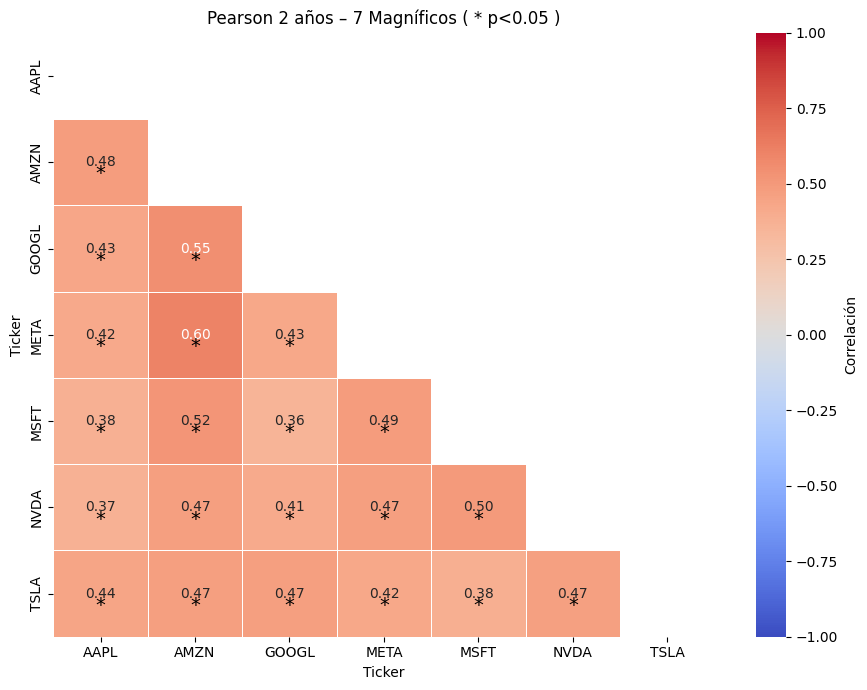

In [30]:
# p-values par a par (más robusto)
pvals = pd.DataFrame(np.ones(pearson_corr.shape), index=tickers, columns=tickers)
for i in tickers:
    for j in tickers:
        if i!=j:
            _, p = stats.pearsonr(returns[i], returns[j])
            pvals.loc[i,j] = p

mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
plt.figure(figsize=(9,7))
sns.heatmap(pearson_corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, linewidths=.5,
            cbar_kws={"label": "Correlación"})
# añade estrellas
for i in range(len(tickers)):
    for j in range(i):
        if pvals.iloc[i,j] < 0.05:
            plt.text(j+0.5, i+0.7, "*", ha='center', color='black', fontsize=14)
plt.title('Pearson 2 años – 7 Magníficos ( * p<0.05 )')
plt.tight_layout()

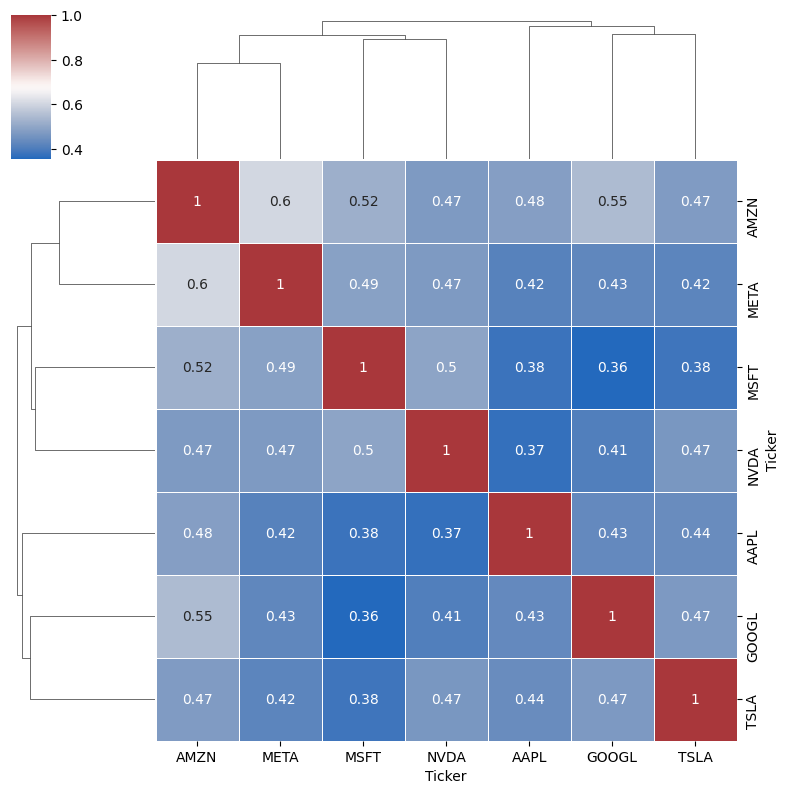

In [31]:
sns.clustermap(pearson_corr, cmap="vlag", annot=True,
               figsize=(8,8), linewidths=.5, method='average')

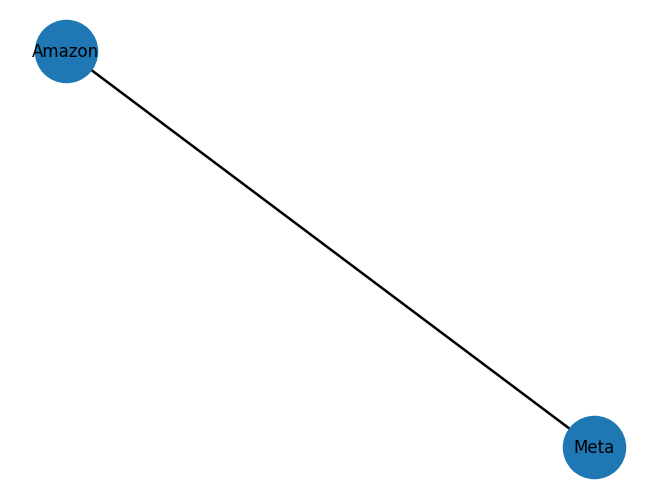

In [32]:
G = nx.Graph()
threshold = 0.6
for i in tickers:
    for j in tickers:
        if i<j and abs(pearson_corr.loc[i,j]) > threshold:
            G.add_edge(nombres[i], nombres[j], weight=pearson_corr.loc[i,j])

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2000,
        width=[d['weight']*3 for _,_,d in G.edges(data=True)])

Text(0, 0.5, 'Pearson')

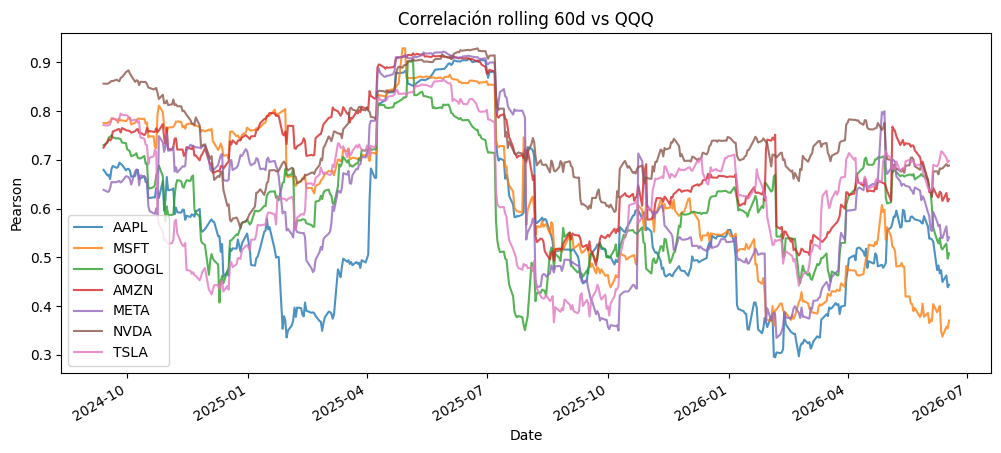

In [33]:
# Correlación rolling vs QQQ y SPY
window = 60 # ~3 meses
rolling = pd.DataFrame()
for t in tickers:
    rolling[t] = returns[t].rolling(window).corr(returns['QQQ'] if 'QQQ' in returns else benchmarks['QQQ'].pct_change())

rolling.plot(figsize=(12,5), alpha=0.8)
plt.title(f'Correlación rolling {window}d vs QQQ')
plt.ylabel('Pearson')

Top: Ticker  Ticker
AMZN    META      0.604939
        GOOGL     0.547115
dtype: float64
Bottom: Ticker  Ticker
TSLA    TSLA     NaN
dtype: float64


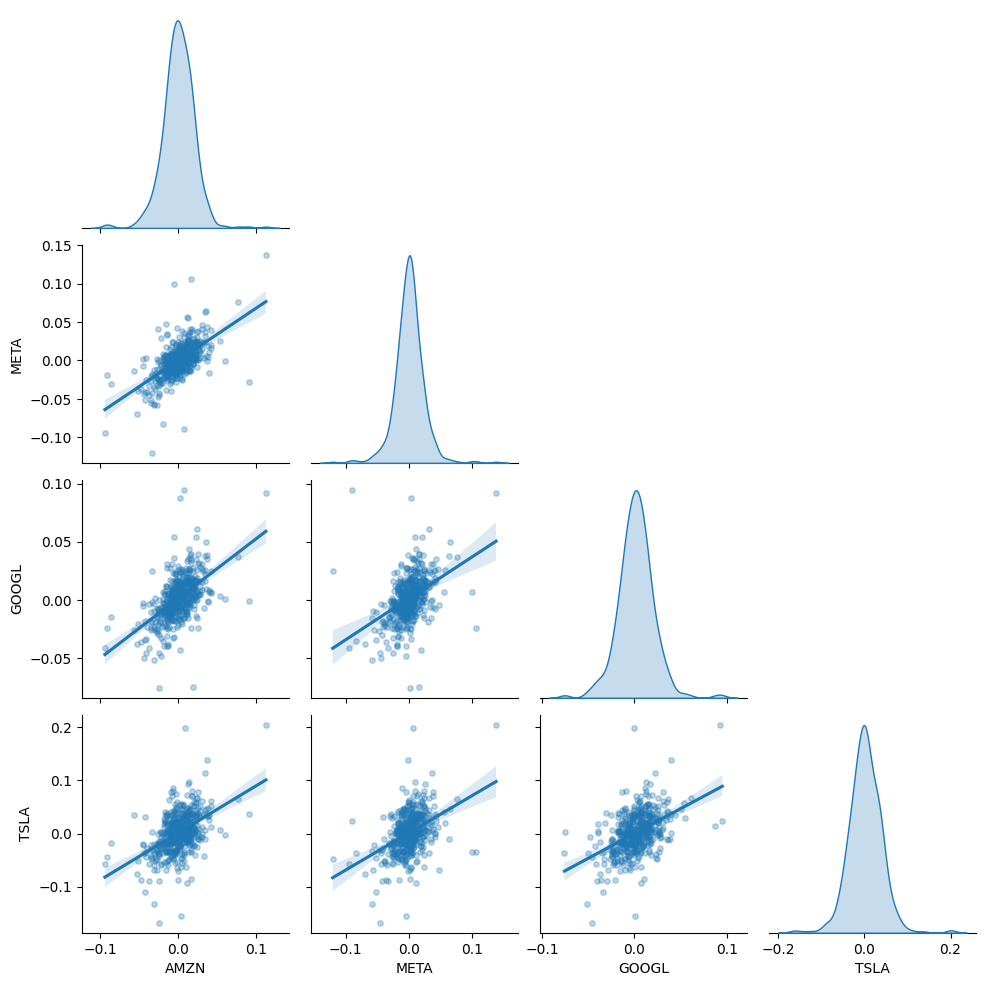

In [ ]:
# 1. trabaja con log_ret
mask = np.triu(np.ones(pearson_corr.shape), k=1).astype(bool)
pairs = pearson_corr.where(mask).stack().sort_values(ascending=False)

top_pairs = pairs.head(2)
bottom_pair = pairs.tail(1)

print("Top:", top_pairs)
print("Bottom:", bottom_pair)

# 3. lista única de tickers, sin repetir
tickers_plot = []
for a, b in list(top_pairs.index) + list(bottom_pair.index):
    tickers_plot.extend([a, b])

tickers_plot = list(dict.fromkeys(tickers_plot))  # mantiene orden y quita duplicados

# 4. pairplot limpio
sns.pairplot(
    returns_log[tickers_plot].dropna(),
    kind='reg',
    diag_kind='kde',
    plot_kws={'scatter_kws': {'alpha': 0.3, 's': 15}},
    corner=True  # opcional, evita la mitad duplicada del gráfico
)

In [ ]:
# El peor par es google con microsoft
pairs = pearson_corr.where(mask).stack().dropna().sort_values(ascending=False)
top_pairs = pairs.head(2)
bottom_pair = pairs.tail(1)
bottom_pair

Ticker  Ticker
GOOGL   MSFT      0.356064
dtype: float64

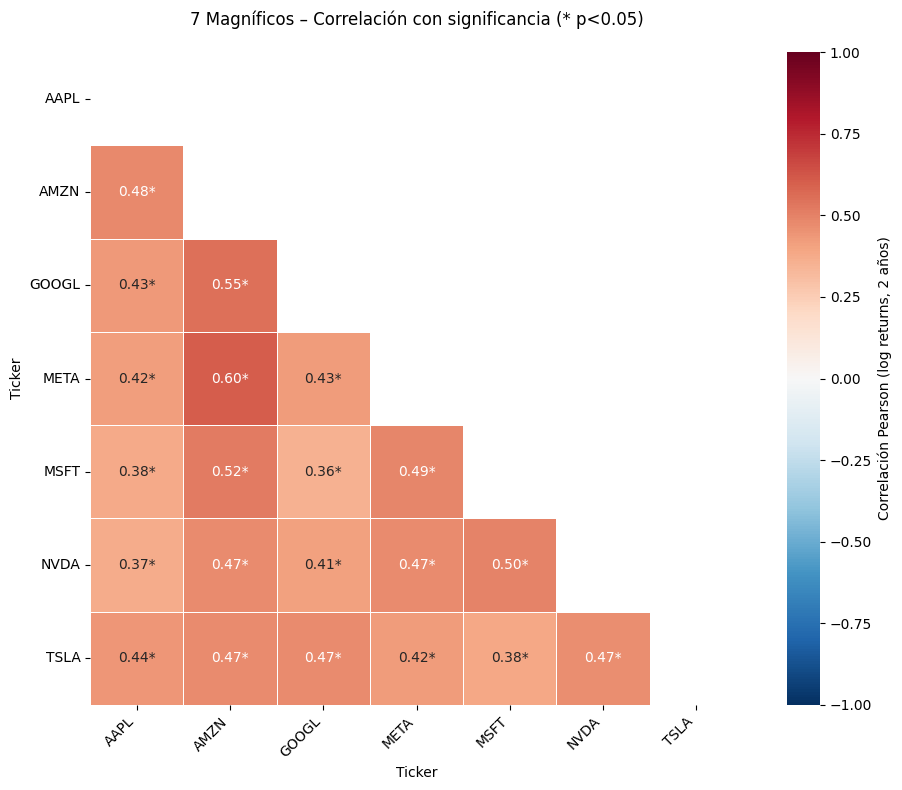

In [ ]:
# 1. máscara para mostrar solo triángulo inferior
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

# 2. anotaciones con * si p < 0.05
annot = pearson_corr.copy().round(2).astype(str)
for i in range(len(pearson_corr)):
    for j in range(len(pearson_corr)):
        if i > j:  # solo abajo
            r = pearson_corr.iloc[i, j]
            p = pearson_pvals.iloc[i, j]
            star = "*" if p < 0.05 else ""
            annot.iloc[i, j] = f"{r:.2f}{star}"
        else:
            annot.iloc[i, j] = ""

# 3. gráfico
plt.figure(figsize=(10,8))
sns.heatmap(
    pearson_corr,
    mask=mask,
    annot=annot,
    fmt="",
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlación Pearson (log returns, 2 años)"},
    square=True
)

plt.title("7 Magníficos – Correlación con significancia (* p<0.05)", pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

####################################################################
## **MÉTODO 2: SPEARMAN CORRELATION**
####################################################################

In [42]:
def spearman_analysis(returns):
    """Correlación de Spearman + p-values"""
    # correlación por rangos
    corr_matrix = returns.corr(method='spearman')

    # p-values par a par
    p_values = pd.DataFrame(
        np.zeros_like(corr_matrix),
        index=corr_matrix.index,
        columns=corr_matrix.columns
    )

    for i in corr_matrix.index:
        for j in corr_matrix.columns:
            if i!= j:
                _, p = spearmanr(returns[i], returns[j], nan_policy='omit')
                p_values.loc[i, j] = p
            else:
                p_values.loc[i, j] = 0.0

    return corr_matrix, p_values

spearman_corr, spearman_pvals = spearman_analysis(returns_log)

Text(0.5, 1.0, 'Spearman - Pearson (positivo = más relación monotónica que lineal)')

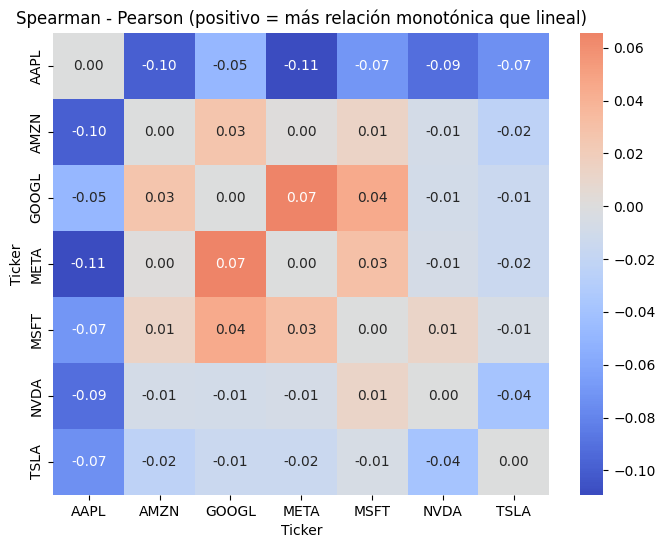

In [43]:
diff = spearman_corr - pearson_corr
plt.figure(figsize=(8,6))
sns.heatmap(diff, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman - Pearson (positivo = más relación monotónica que lineal)")

In [44]:
mask = np.triu(np.ones(spearman_corr.shape), k=1).astype(bool)
top3_spearman = spearman_corr.where(mask).stack().sort_values(ascending=False).head(3)
print(top3_spearman)

Ticker  Ticker
AMZN    META      0.606008
        GOOGL     0.573711
        MSFT      0.534952
dtype: float64


In [45]:
top3_spearman

Ticker  Ticker
AMZN    META      0.606008
        GOOGL     0.573711
        MSFT      0.534952
dtype: float64

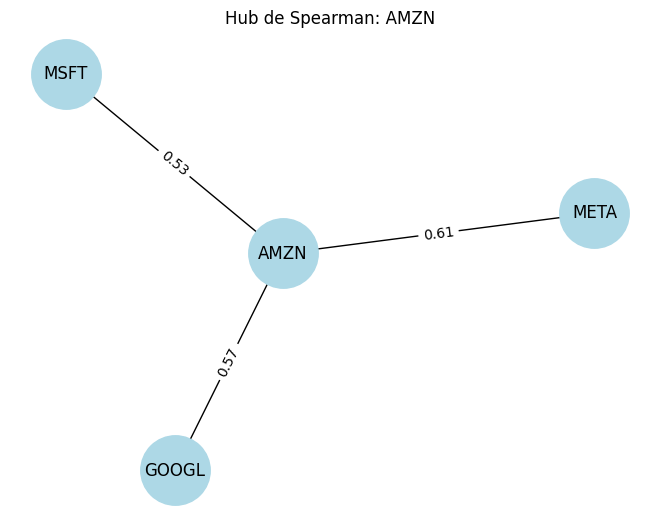

In [46]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
for (a,b), rho in top3_spearman.items():
    G.add_edge(a, b, weight=rho)

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2500, node_color='lightblue')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels={k:f"{v:.2f}" for k,v in labels.items()})
plt.title("Hub de Spearman: AMZN")
plt.show()

In [47]:
# máscara del triángulo superior (sin duplicados ni diagonal)
mask = np.triu(np.ones(pearson_corr.shape), k=1).astype(bool)

# tabla comparativa
comparativa = pd.DataFrame({
    'Pearson': pearson_corr.where(mask).stack(),
    'Spearman': spearman_corr.where(mask).stack()
})
comparativa['Diferencia'] = comparativa['Spearman'] - comparativa['Pearson']
comparativa = comparativa.sort_values('Spearman', ascending=False)

# top 5 para ver el nuevo orden
print("Top 5 pares por Spearman (con log_returns):")
print(comparativa.head(5).round(3))

Top 5 pares por Spearman (con log_returns):
               Pearson  Spearman  Diferencia
Ticker Ticker                               
AMZN   META      0.605     0.606       0.001
       GOOGL     0.547     0.574       0.027
       MSFT      0.522     0.535       0.013
META   MSFT      0.489     0.519       0.031
MSFT   NVDA      0.496     0.508       0.012


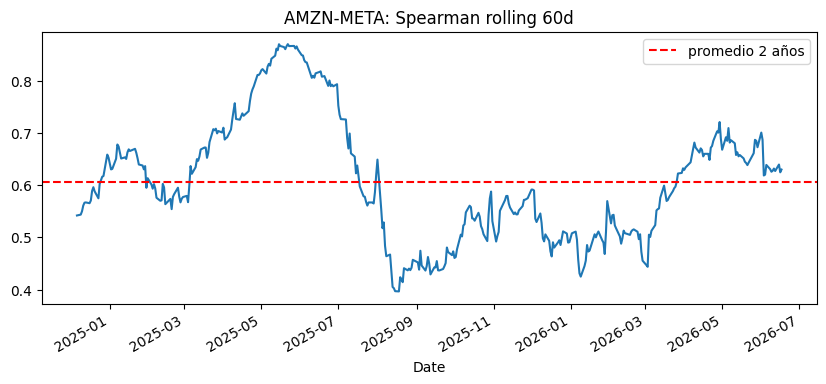

In [51]:
window = 60

# 1. Convertimos las series de retornos a sus rangos móviles dentro de la ventana de 60 días
rank_amzn = returns_log['AMZN'].rolling(window).rank()
rank_meta = returns_log['META'].rolling(window).rank()

# 2. Calculamos la correlación de Pearson sobre los rangos (que equivale a Spearman)
rolling_spearman = rank_amzn.rolling(window).corr(rank_meta)

# Tu código de graficación se mantiene igual
rolling_spearman.plot(figsize=(10,4), title='AMZN-META: Spearman rolling 60d')
plt.axhline(0.606, color='red', linestyle='--', label='promedio 2 años')
plt.legend()
plt.show()


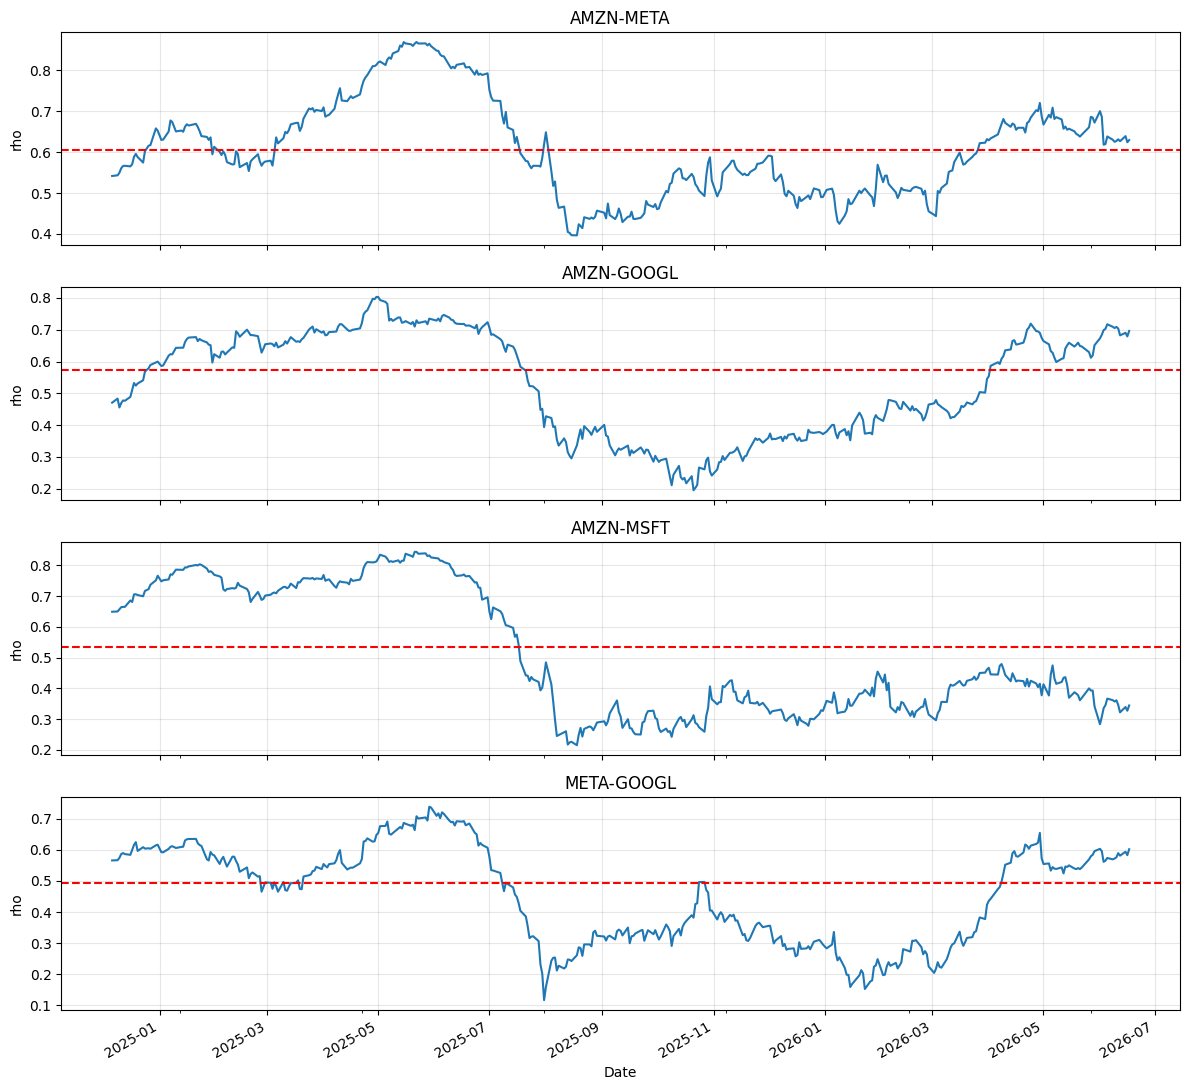

In [55]:
pares = [('AMZN','META'), ('AMZN','GOOGL'), ('AMZN','MSFT'), ('META','GOOGL')]
fig, axes = plt.subplots(4,1, figsize=(12,11), sharex=True)

for ax, (a,b) in zip(axes, pares):
    ra = returns_log[a].rolling(window).rank()
    rb = returns_log[b].rolling(window).rank()
    roll = ra.rolling(window).corr(rb)
    roll.plot(ax=ax)
    ax.axhline(spearman_corr.loc[a,b], color='red', linestyle='--')
    ax.set_title(f'{a}-{b}')
    ax.set_ylabel('rho')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

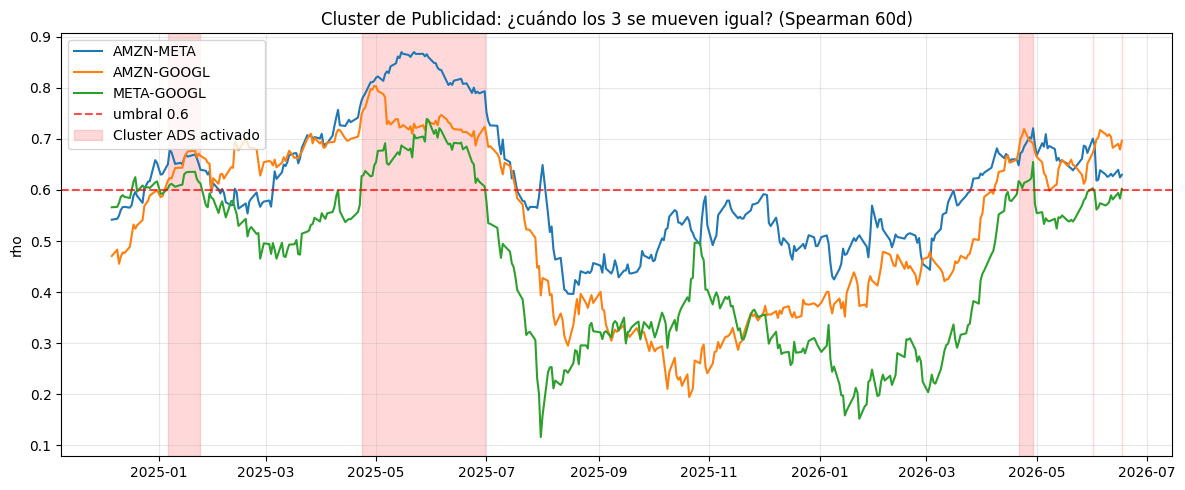

Periodos con cluster activo:
Última activación: 2026-06-17
Días totales en cluster en 2 años: 69 de 500


In [56]:
window = 60
umbral = 0.6

# 1. calcula los tres rolling Spearman con tu método
def rolling_spearman(a, b):
    ra = returns_log[a].rolling(window).rank()
    rb = returns_log[b].rolling(window).rank()
    return ra.rolling(window).corr(rb)

r_amzn_meta = rolling_spearman('AMZN','META')
r_amzn_googl = rolling_spearman('AMZN','GOOGL')
r_meta_googl = rolling_spearman('META','GOOGL')

# 2. señal de cluster
cluster_activo = (r_amzn_meta > umbral) & (r_amzn_googl > umbral) & (r_meta_googl > umbral)

# 3. gráfico
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(r_amzn_meta, label='AMZN-META')
ax.plot(r_amzn_googl, label='AMZN-GOOGL')
ax.plot(r_meta_googl, label='META-GOOGL')
ax.axhline(umbral, color='red', linestyle='--', alpha=0.7, label='umbral 0.6')

# sombrea las zonas donde los tres están arriba
ax.fill_between(cluster_activo.index, 0, 1, where=cluster_activo,
                color='red', alpha=0.15, transform=ax.get_xaxis_transform(),
                label='Cluster ADS activado')

ax.set_title('Cluster de Publicidad: ¿cuándo los 3 se mueven igual? (Spearman 60d)')
ax.set_ylabel('rho')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. opcional: fechas exactas
fechas_cluster = cluster_activo[cluster_activo].index
print("Periodos con cluster activo:")
for start, end in zip(fechas_cluster[::50], fechas_cluster[::50]): # ejemplo simple
    pass
print(f"Última activación: {fechas_cluster[-1].date() if len(fechas_cluster)>0 else 'ninguna'}")
print(f"Días totales en cluster en 2 años: {cluster_activo.sum()} de {len(cluster_activo)}")

In [57]:
if r_meta_googl.iloc[-1] > 0.6 and cluster_activo.iloc[-1]:
    print("ALERTA: Cluster ADS confirmado")
elif r_meta_googl.iloc[-1] > 0.58:
    print("Vigilancia: a 2 puntos de activar cluster")

ALERTA: Cluster ADS confirmado


In [58]:
window = 60
pares = [('AMZN','META'), ('AMZN','GOOGL'), ('AMZN','MSFT'), ('META','GOOGL')]

def rolling_spearman(a,b):
    ra = returns_log[a].rolling(window).rank()
    rb = returns_log[b].rolling(window).rank()
    return ra.rolling(window).corr(rb)

tabla = []
for a,b in pares:
    roll = rolling_spearman(a,b)
    promedio = spearman_corr.loc[a,b] # tu promedio de 2 años
    max_2025 = roll['2025'].max()
    hoy = roll.iloc[-1]
    tabla.append([f'{a}-{b}', round(promedio,3), round(max_2025,3), round(hoy,3)])

resumen = pd.DataFrame(tabla, columns=['Par','Promedio_2a','Max_2025','Hoy_17jun2026'])
print(resumen.to_string(index=False))

       Par  Promedio_2a  Max_2025  Hoy_17jun2026
 AMZN-META        0.606     0.870          0.630
AMZN-GOOGL        0.574     0.803          0.696
 AMZN-MSFT        0.535     0.844          0.344
META-GOOGL        0.494     0.739          0.602


* 2025 fue el año del todo-junto. Los cuatro pares tocaron 0.73 a 0.87 en junio. Ahí Pearson y Spearman te daban  casi lo mismo porque no había outliers, todo subía.
* Septiembre 2025 rompió el mercado. Por eso el promedio de 2 años (0.49 a 0.60) queda tan lejos de esos máximos.
* Hoy estás en un punto bisagra. AMZN-GOOGL en 0.696 y AMZN-META en 0.630 ya están en régimen alto

####################################################################
## **MÉTODO 3: DISTANCE CORRELATION**
####################################################################

In [61]:
pares = [('AMZN','META'), ('AMZN','GOOGL'), ('AMZN','MSFT'), ('META','GOOGL')]

resultados = []
for a,b in pares:
    x = returns_log[a].dropna().values
    y = returns_log[b].dropna().values
    # alinea por fecha
    df = returns_log[[a,b]].dropna()
    d = dcor.distance_correlation(df[a].values, df[b].values)

    # compara con lo que ya tienes
    pearson = df[a].corr(df[b])
    spearman = df[a].corr(df[b], method='spearman')

    resultados.append([f'{a}-{b}', round(pearson,3), round(spearman,3), round(d,3)])

tabla_dcor = pd.DataFrame(resultados, columns=['Par','Pearson','Spearman','dCor'])
print(tabla_dcor.to_string(index=False))

       Par  Pearson  Spearman  dCor
 AMZN-META    0.605     0.606 0.590
AMZN-GOOGL    0.547     0.574 0.551
 AMZN-MSFT    0.522     0.535 0.528
META-GOOGL    0.428     0.494 0.474


* AMZN-META 0.590 vs 0.606 – dCor es incluso un poco menor que Pearson y Spearman. Eso es señal de relación casi puramente lineal, sin estructura curva escondida. No hay "magia no lineal", es simplemente que se mueven juntos.
* AMZN-GOOGL 0.551 vs 0.574 – pasa lo mismo. La pequeña ganancia de Spearman sobre Pearson no se traduce en más dependencia compleja.
* AMZN-MSFT 0.528 vs 0.535 – idéntico. Cloud es lineal.
* META-GOOGL 0.474 vs 0.494 – aquí está lo interesante. Spearman subía de 0.428 a 0.494 y pensamos "hay monotonicidad", pero dCor se queda en 0.474, por debajo de Spearman. Eso te dice que esa ganancia no venía de una dependencia compleja, venía de algunos outliers que Spearman ordena mejor, pero que no aportan dependencia real extra.

In [63]:
def rolling_dcor(s1, s2, window=60):
    return s1.rolling(window).apply(lambda x: dcor.distance_correlation(
        x, s2.loc[x.index].values), raw=False)

r_dcor = rolling_dcor(returns_log['AMZN'], returns_log['META'])
r_dcor

Date
2024-06-20         NaN
2024-06-21         NaN
2024-06-24         NaN
2024-06-25         NaN
2024-06-26         NaN
                ...   
2026-06-11    0.624716
2026-06-12    0.621482
2026-06-15    0.637097
2026-06-16    0.627169
2026-06-17    0.644178
Name: AMZN, Length: 500, dtype: float64

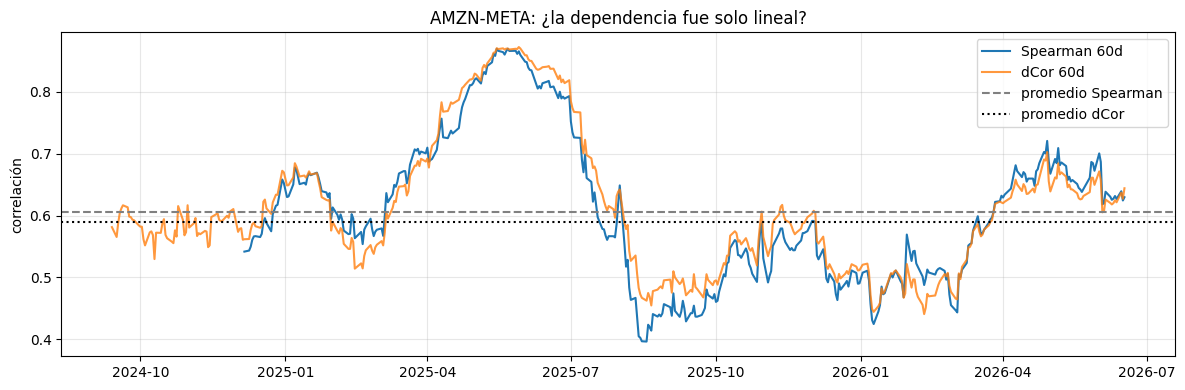

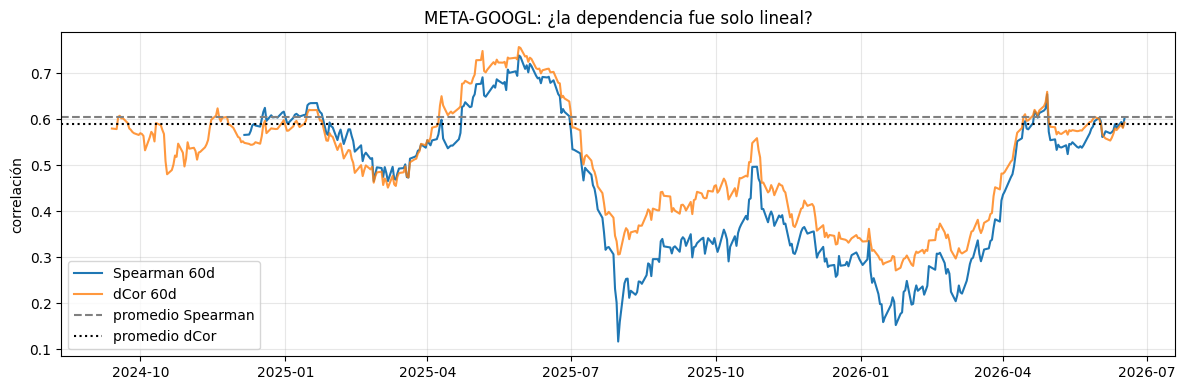

In [66]:
window = 60
a, b = 'AMZN', 'META'

# rolling dCor
def rolling_dcor(s1, s2):
    return s1.rolling(window).apply(
        lambda x: dcor.distance_correlation(x.values, s2.loc[x.index].values),
        raw=False
    )

dcor_roll = rolling_dcor(returns_log[a], returns_log[b])

# tu Spearman rolling ya lo tienes, si no:
ra = returns_log[a].rolling(window).rank()
rb = returns_log[b].rolling(window).rank()
spearman_roll = ra.rolling(window).corr(rb)

# plot comparativo
plt.figure(figsize=(12,4))
plt.plot(spearman_roll, label='Spearman 60d')
plt.plot(dcor_roll, label='dCor 60d', alpha=0.8)
plt.axhline(0.606, color='gray', linestyle='--', label='promedio Spearman')
plt.axhline(0.590, color='black', linestyle=':', label='promedio dCor')
plt.title('AMZN-META: ¿la dependencia fue solo lineal?')
plt.ylabel('correlación')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



window = 60
a, b = 'META','GOOGL'

# rolling dCor
def rolling_dcor(s1, s2):
    return s1.rolling(window).apply(
        lambda x: dcor.distance_correlation(x.values, s2.loc[x.index].values),
        raw=False
    )

dcor_roll = rolling_dcor(returns_log[a], returns_log[b])

# tu Spearman rolling ya lo tienes, si no:
ra = returns_log[a].rolling(window).rank()
rb = returns_log[b].rolling(window).rank()
spearman_roll = ra.rolling(window).corr(rb)

# plot comparativo
plt.figure(figsize=(12,4))
plt.plot(spearman_roll, label='Spearman 60d')
plt.plot(dcor_roll, label='dCor 60d', alpha=0.8)
plt.axhline(0.606, color='gray', linestyle='--', label='promedio Spearman')
plt.axhline(0.590, color='black', linestyle=':', label='promedio dCor')
plt.title('META-GOOGL: ¿la dependencia fue solo lineal?')
plt.ylabel('correlación')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

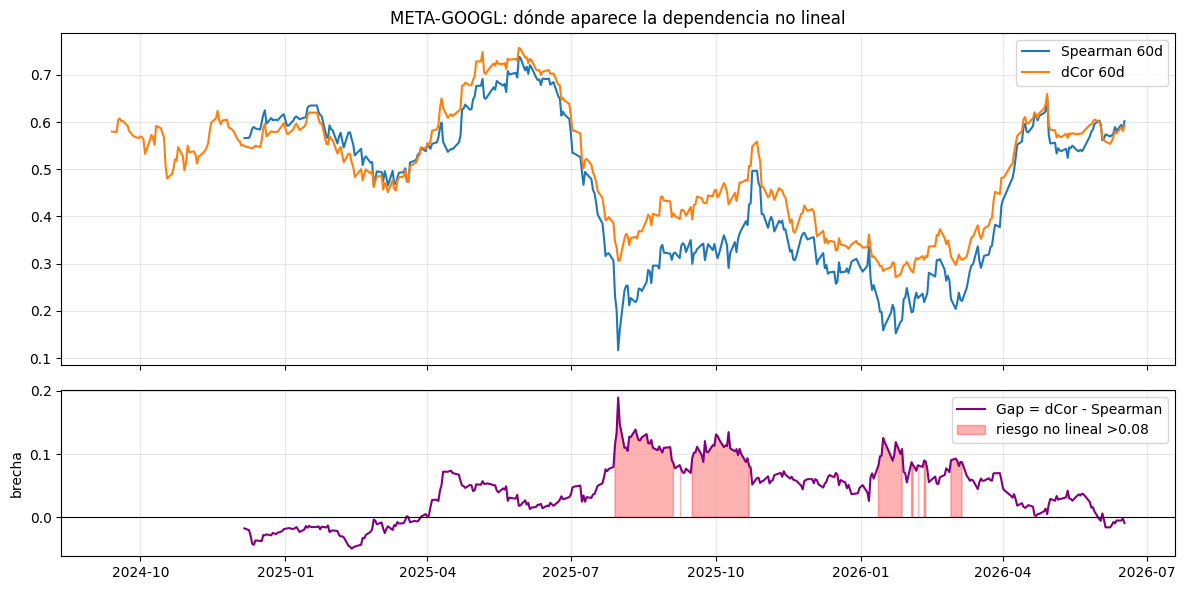

Promedio brecha: 0.043
Máxima brecha: 0.189 el 2025-07-31
Días con brecha >0.08: 77 de 500
Primer periodo fuerte: 2025-07-29 a 2026-03-06


In [67]:
a, b = 'META', 'GOOGL'
window = 60

# ya los tienes, si no recalcula rápido
ra = returns_log[a].rolling(window).rank()
rb = returns_log[b].rolling(window).rank()
spearman_roll = ra.rolling(window).corr(rb)

dcor_roll = returns_log[a].rolling(window).apply(
    lambda x: dcor.distance_correlation(x.values, returns_log[b].loc[x.index].values),
    raw=False
)

# 1. la brecha
gap = dcor_roll - spearman_roll

# 2. plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,6), sharex=True, gridspec_kw={'height_ratios':[2,1]})

# arriba las dos curvas que ya conoces
ax1.plot(spearman_roll, label='Spearman 60d')
ax1.plot(dcor_roll, label='dCor 60d')
ax1.set_title('META-GOOGL: dónde aparece la dependencia no lineal')
ax1.legend()
ax1.grid(alpha=0.3)

# abajo la brecha
ax2.plot(gap, color='purple', label='Gap = dCor - Spearman')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.fill_between(gap.index, 0, gap, where=gap>0.08, color='red', alpha=0.3, label='riesgo no lineal >0.08')
ax2.set_ylabel('brecha')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 3. fechas clave
alto_riesgo = gap[gap > 0.08]
print(f"Promedio brecha: {gap.mean():.3f}")
print(f"Máxima brecha: {gap.max():.3f} el {gap.idxmax().date()}")
print(f"Días con brecha >0.08: {len(alto_riesgo)} de {len(gap)}")
print("Primer periodo fuerte:", alto_riesgo.index.min().date(), "a", alto_riesgo.index.max().date())

* **Script pearson, sperman y distacia de correlación**

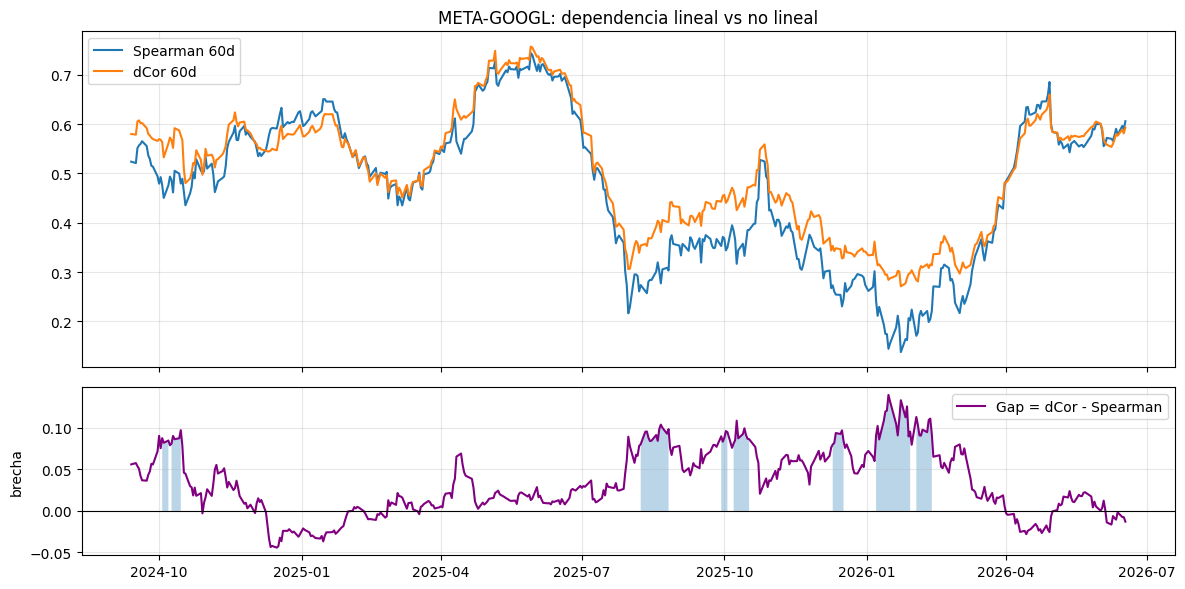

       Par  Pearson  Spearman  dCor  Gap_prom  Gap_max Fecha_max_gap  Dias_gap_alto
META-GOOGL    0.428     0.494 0.474     0.034     0.14    2026-01-15             70


In [73]:
def analiza_par(t1, t2, returns_log, window=60, umbral_gap=0.08):
    df = returns_log[[t1, t2]].dropna()

    # 1. métricas globales
    pearson = df.corr().iloc[0, 1]
    spearman = df.corr(method='spearman').iloc[0, 1]
    dcor_val = dcor.distance_correlation(df[t1].values, df[t2].values)

    # 2. rolling
    spearman_roll = []
    dcor_roll = []
    idxs = []

    for i in range(window - 1, len(df)):
        w = df.iloc[i-window+1:i+1]

        sp = w.corr(method='spearman').iloc[0, 1]
        dc = dcor.distance_correlation(w[t1].values, w[t2].values)

        spearman_roll.append(sp)
        dcor_roll.append(dc)
        idxs.append(w.index[-1])

    spearman_roll = pd.Series(spearman_roll, index=idxs)
    dcor_roll = pd.Series(dcor_roll, index=idxs)

    gap = dcor_roll - spearman_roll

    # 3. tabla resumen
    resumen = pd.DataFrame([{
        'Par': f'{t1}-{t2}',
        'Pearson': round(pearson, 3),
        'Spearman': round(spearman, 3),
        'dCor': round(dcor_val, 3),
        'Gap_prom': round(gap.mean(), 3),
        'Gap_max': round(gap.max(), 3),
        'Fecha_max_gap': gap.idxmax().date(),
        'Dias_gap_alto': int((gap > umbral_gap).sum())
    }])

    # 4. plot
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(12, 6), sharex=True,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    ax1.plot(spearman_roll.index, spearman_roll, label='Spearman 60d')
    ax1.plot(dcor_roll.index, dcor_roll, label='dCor 60d')
    ax1.set_title(f'{t1}-{t2}: dependencia lineal vs no lineal')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(gap.index, gap, color='purple', label='Gap = dCor - Spearman')
    ax2.axhline(0, color='black', lw=0.8)
    ax2.fill_between(gap.index, 0, gap, where=gap > umbral_gap, alpha=0.3)
    ax2.set_ylabel('brecha')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return resumen, spearman_roll, dcor_roll, gap


# EJEMPLO DE USO
resumen_mg, _, _, _ = analiza_par('META', 'GOOGL', returns_log)
print(resumen_mg.to_string(index=False))

# para los otros pares
# analiza_par('AMZN','META', returns_log)
# analiza_par('AMZN','GOOGL', returns_log)
# analiza_par('AMZN','MSFT', returns_log)

####################################################################
## **MÉTODO 4: COINTEGRATION**
####################################################################

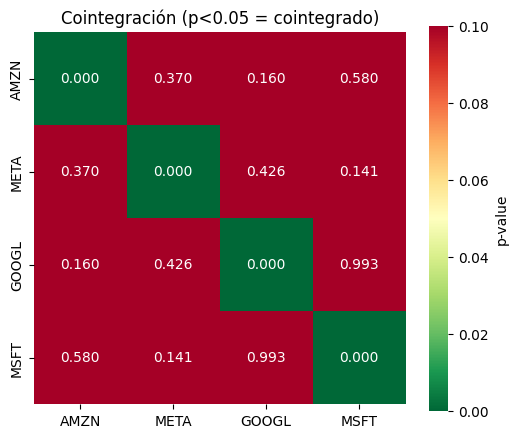

  Stock1 Stock2  Cointegration_Score  P_Value  Is_Cointegrated
4   META   MSFT               -2.880   0.1415            False
1   AMZN  GOOGL               -2.819   0.1598            False
0   AMZN   META               -2.306   0.3705            False
3   META  GOOGL               -2.197   0.4257            False
2   AMZN   MSFT               -1.899   0.5803            False
5  GOOGL   MSFT                0.542   0.9929            False


In [ ]:
def test_cointegration(prices, tickers=None, p_threshold=0.05):
    if tickers is None:
        tickers = prices.columns.tolist()

    results = []
    for i, s1 in enumerate(tickers):
        for j, s2 in enumerate(tickers):
            if i < j:
                y0 = prices[s1].dropna()
                y1 = prices[s2].dropna()
                y0, y1 = y0.align(y1, join='inner')

                score, pvalue, _ = coint(y0, y1)

                results.append({
                    'Stock1': s1,
                    'Stock2': s2,
                    'Cointegration_Score': round(score, 3),
                    'P_Value': round(pvalue, 4),
                    'Is_Cointegrated': pvalue < p_threshold
                })

    coint_df = pd.DataFrame(results).sort_values('P_Value')

    # Matriz de p-valores
    pval_matrix = pd.DataFrame(np.ones((len(tickers), len(tickers))),
                               index=tickers, columns=tickers)
    for _, r in coint_df.iterrows():
        pval_matrix.loc[r['Stock1'], r['Stock2']] = r['P_Value']
        pval_matrix.loc[r['Stock2'], r['Stock1']] = r['P_Value']

    # ---- CORRECCIÓN: asignar la diagonal sin usar np.fill_diagonal ----
    for i in range(len(pval_matrix)):
        pval_matrix.iloc[i, i] = 0.0

    # Heatmap
    fig, ax = plt.subplots(figsize=(6,5))
    sns.heatmap(pval_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r',
                vmin=0, vmax=0.1, square=True, cbar_kws={'label':'p-value'})
    ax.set_title('Cointegración (p<0.05 = cointegrado)')
    plt.show()

    return coint_df, pval_matrix

prices = close_data # Precio de cierre de las acciones
coint_df, pval_matrix = test_cointegration(prices, ['AMZN','META','GOOGL','MSFT'])
print(coint_df)

* Si tu objetivo era diversificación, está bien: al no estar cointegrados, no se arrastran eternamente.
* Si buscabas pares para arbitraje, descarta estos cuatro. Tendrías que probar con pares del mismo subsector más estrecho (por ejemplo META-SNAP, GOOGL-META en ventanas más largas de 5 años, o AMZN-MELI).
* Cuando el gap subió a 0.189 el 31-jul-2025, la cointegración ya era inexistente, así que ese pico no era "desviación", era el régimen real.

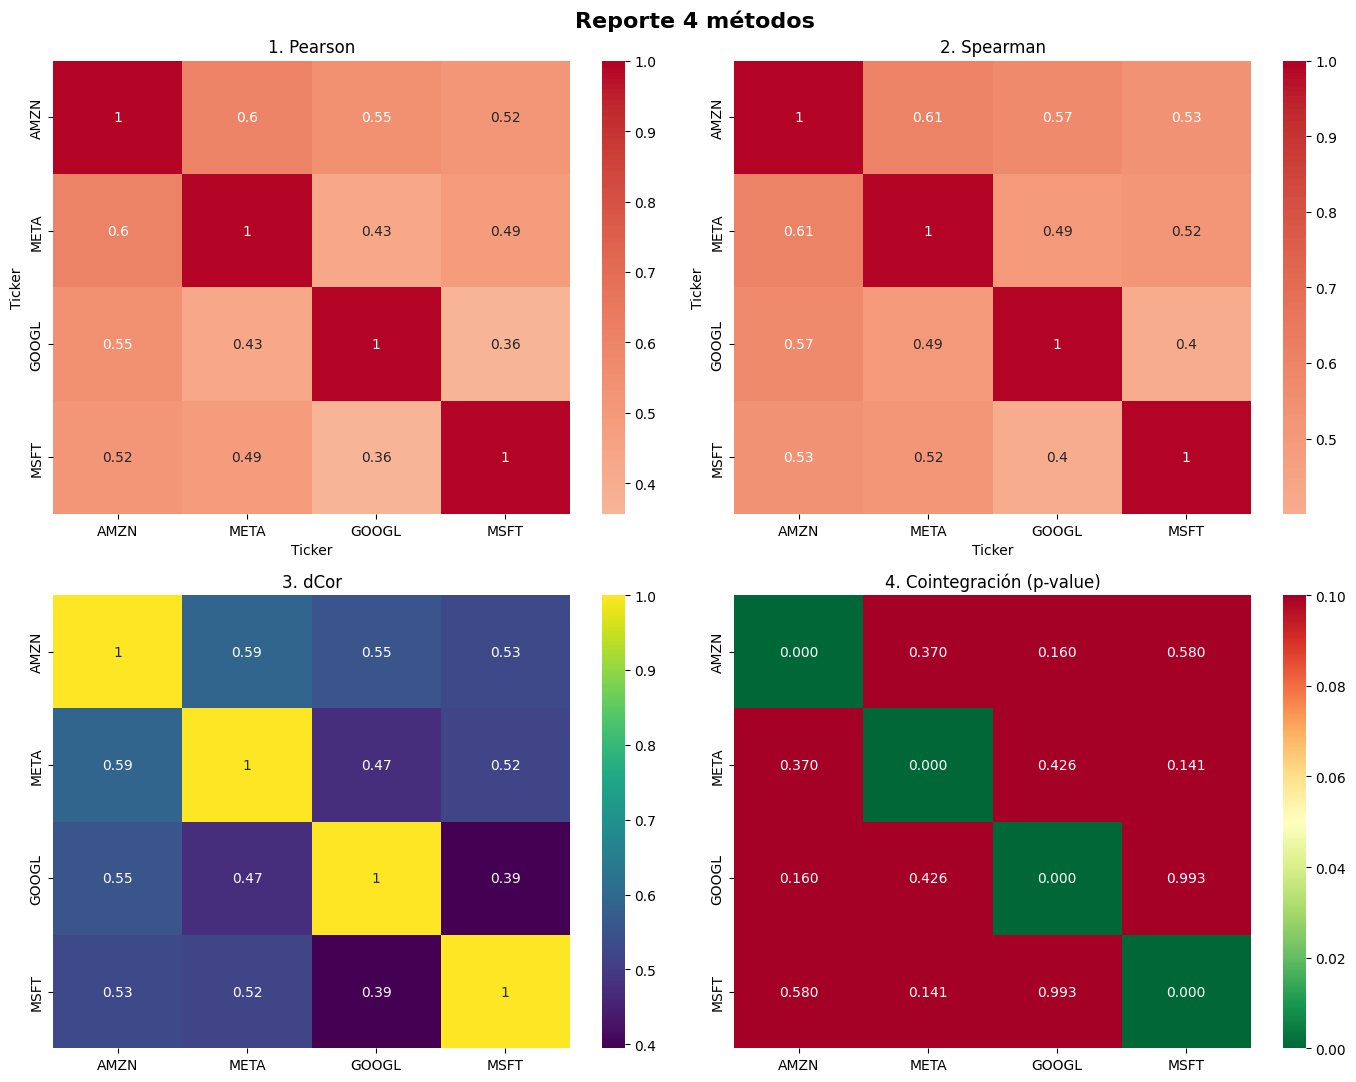


--- Gap dCor-Spearman ---
       Par  Gap_prom  Gap_max  Fecha_max  Dias_alto
 AMZN-META     0.009    0.078 2025-08-13          0
AMZN-GOOGL     0.023    0.143 2025-08-14         38
 AMZN-MSFT     0.032    0.146 2025-08-13         59
META-GOOGL     0.043    0.189 2025-07-31         77
 META-MSFT     0.045    0.128 2025-10-03         71
GOOGL-MSFT     0.062    0.334 2026-01-23        102

--- Cointegración ---
       Par  Score  p_value
 META-MSFT -2.880   0.1415
AMZN-GOOGL -2.819   0.1598
 AMZN-META -2.306   0.3705
META-GOOGL -2.197   0.4257
 AMZN-MSFT -1.899   0.5803
GOOGL-MSFT  0.542   0.9929


In [ ]:
def reporte_completo(prices, returns_log, tickers, window=60, gap_umbral=0.08):
    import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, dcor
    from statsmodels.tsa.stattools import coint

    pearson_m = returns_log[tickers].corr()
    spearman_m = returns_log[tickers].corr(method='spearman')

    dcor_m = pd.DataFrame(index=tickers, columns=tickers, dtype=float)
    for i in tickers:
        for j in tickers:
            dcor_m.loc[i,j] = 1.0 if i==j else dcor.distance_correlation(
                returns_log[i].dropna().values, returns_log[j].dropna().values)

    coint_rows = []
    for i,a in enumerate(tickers):
        for j,b in enumerate(tickers):
            if i<j:
                y0,y1 = prices[a].dropna().align(prices[b].dropna(), join='inner')
                score,pval,_ = coint(y0.values, y1.values.reshape(-1,1))
                coint_rows.append({'Par':f'{a}-{b}', 'Score':round(score,3), 'p_value':round(pval,4)})
    coint_df = pd.DataFrame(coint_rows).sort_values('p_value')

    gap_summary = []
    for i,a in enumerate(tickers):
        for j,b in enumerate(tickers):
            if i<j:
                ra = returns_log[a].rolling(window).rank()
                rb = returns_log[b].rolling(window).rank()
                spear_roll = ra.rolling(window).corr(rb)
                dcor_roll = returns_log[a].rolling(window).apply(
                    lambda x: dcor.distance_correlation(x.values, returns_log[b].loc[x.index].values), raw=False)
                gap = dcor_roll - spear_roll
                gap_summary.append({
                    'Par':f'{a}-{b}',
                    'Gap_prom':round(gap.mean(),3),
                    'Gap_max':round(gap.max(),3),
                    'Fecha_max':gap.idxmax().date(),
                    'Dias_alto':int((gap>gap_umbral).sum())
                })
    gap_df = pd.DataFrame(gap_summary)

    fig, axes = plt.subplots(2,2, figsize=(14,11))
    sns.heatmap(pearson_m, annot=True, cmap='coolwarm', center=0, ax=axes[0,0]); axes[0,0].set_title('1. Pearson')
    sns.heatmap(spearman_m, annot=True, cmap='coolwarm', center=0, ax=axes[0,1]); axes[0,1].set_title('2. Spearman')
    sns.heatmap(dcor_m.astype(float), annot=True, cmap='viridis', ax=axes[1,0]); axes[1,0].set_title('3. dCor')

    pval_m = pd.DataFrame(1.0, index=tickers, columns=tickers)
    for _,r in coint_df.iterrows():
        a,b = r['Par'].split('-')
        pval_m.loc[a,b] = r['p_value']; pval_m.loc[b,a] = r['p_value']
    for i in range(len(pval_m)): # <-- CORRECCIÓN
        pval_m.iloc[i,i] = 0.0
    sns.heatmap(pval_m, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0, vmax=0.1, ax=axes[1,1])
    axes[1,1].set_title('4. Cointegración (p-value)')

    plt.suptitle('Reporte 4 métodos', fontsize=16, fontweight='bold')
    plt.tight_layout(); plt.show()

    return {'pearson':pearson_m,'spearman':spearman_m,'dcor':dcor_m,
            'cointegracion':coint_df,'gap_resumen':gap_df}


# === USO ===
resultados = reporte_completo(
    prices = close_data,
    returns_log = returns_log,
    tickers = ['AMZN','META','GOOGL','MSFT'],
    window = 60
)

print("\n--- Gap dCor-Spearman ---")
print(resultados['gap_resumen'].to_string(index=False))

print("\n--- Cointegración ---")
print(resultados['cointegracion'].to_string(index=False))

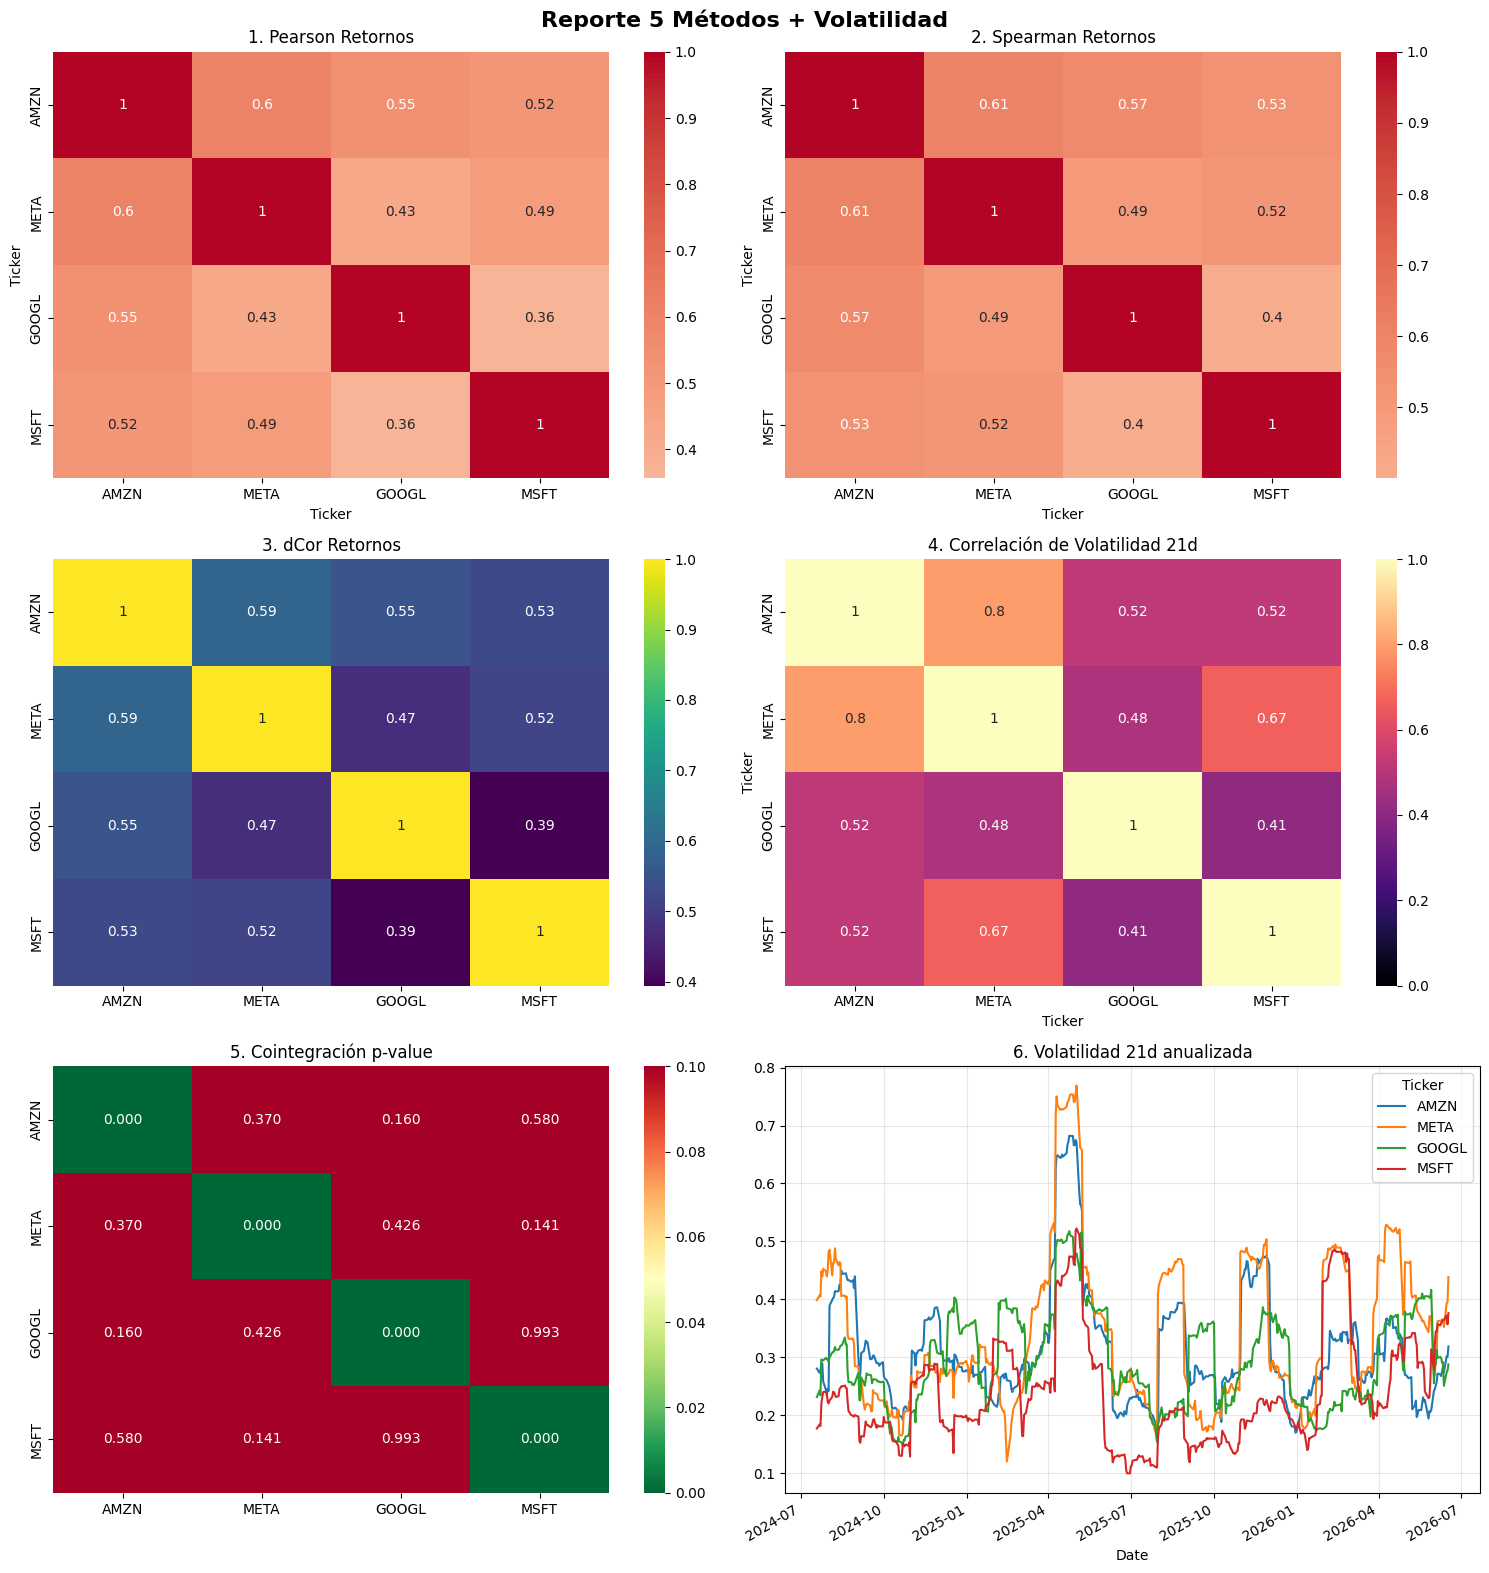


Correlación de volatilidades:
Ticker  AMZN  META  GOOGL  MSFT
Ticker                         
AMZN    1.00  0.80   0.52  0.52
META    0.80  1.00   0.48  0.67
GOOGL   0.52  0.48   1.00  0.41
MSFT    0.52  0.67   0.41  1.00


In [ ]:
def reporte_completo_v2(prices, returns_log, tickers, window=60):

    # 1. Retornos
    pearson_m = returns_log[tickers].corr()
    spearman_m = returns_log[tickers].corr(method='spearman')

    dcor_m = pd.DataFrame(index=tickers, columns=tickers, dtype=float)
    for i in tickers:
        for j in tickers:
            dcor_m.loc[i,j] = 1.0 if i==j else dcor.distance_correlation(
                returns_log[i].dropna(), returns_log[j].dropna())

    # 2. Volatilidad 21d anualizada
    vol_21d = returns_log[tickers].rolling(21).std() * np.sqrt(252)
    vol_corr = vol_21d.corr() # correlación de volatilidades

    # 3. Cointegración
    coint_rows = []
    for i,a in enumerate(tickers):
        for j,b in enumerate(tickers):
            if i<j:
                y0,y1 = prices[a].dropna().align(prices[b].dropna(), join='inner')
                score,pval,_ = coint(y0.values, y1.values.reshape(-1,1))
                coint_rows.append({'Par':f'{a}-{b}', 'p_value':round(pval,4)})
    coint_df = pd.DataFrame(coint_rows)

    # 4. Gap
    gap_rows = []
    for i,a in enumerate(tickers):
        for j,b in enumerate(tickers):
            if i<j:
                spear_roll = returns_log[a].rolling(window).rank().rolling(window).corr(
                             returns_log[b].rolling(window).rank())
                dcor_roll = returns_log[a].rolling(window).apply(
                    lambda x: dcor.distance_correlation(x, returns_log[b].loc[x.index]), raw=False)
                gap = dcor_roll - spear_roll
                gap_rows.append({'Par':f'{a}-{b}', 'Gap_max':round(gap.max(),3),
                                 'Dias_alto':int((gap>0.08).sum())})
    gap_df = pd.DataFrame(gap_rows)

    # 5. PLOT 3x2
    fig, axes = plt.subplots(3,2, figsize=(15,16))
    axes = axes.flatten()

    sns.heatmap(pearson_m, annot=True, cmap='coolwarm', center=0, ax=axes[0]); axes[0].set_title('1. Pearson Retornos')
    sns.heatmap(spearman_m, annot=True, cmap='coolwarm', center=0, ax=axes[1]); axes[1].set_title('2. Spearman Retornos')
    sns.heatmap(dcor_m.astype(float), annot=True, cmap='viridis', ax=axes[2]); axes[2].set_title('3. dCor Retornos')
    sns.heatmap(vol_corr, annot=True, cmap='magma', vmin=0, vmax=1, ax=axes[3]); axes[3].set_title('4. Correlación de Volatilidad 21d')

    pval_m = pd.DataFrame(1.0, index=tickers, columns=tickers)
    for _,r in coint_df.iterrows():
        a,b = r['Par'].split('-'); pval_m.loc[a,b]=r['p_value']; pval_m.loc[b,a]=r['p_value']
    for i in range(len(pval_m)): pval_m.iloc[i,i]=0
    sns.heatmap(pval_m, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0, vmax=0.1, ax=axes[4])
    axes[4].set_title('5. Cointegración p-value')

    # Panel extra: serie de volatilidad
    vol_21d.plot(ax=axes[5], linewidth=1.5); axes[5].set_title('6. Volatilidad 21d anualizada'); axes[5].grid(alpha=0.3)

    plt.suptitle('Reporte 5 Métodos + Volatilidad', fontsize=16, fontweight='bold')
    plt.tight_layout(); plt.show()

    return {'vol_corr': vol_corr, 'vol_series': vol_21d, 'gap': gap_df, 'coint': coint_df}

# USO
res = reporte_completo_v2(close_data, returns_log, ['AMZN','META','GOOGL','MSFT'])
print("\nCorrelación de volatilidades:")
print(res['vol_corr'].round(2))

* AMZN-META: Pearson 0.60, vol_corr 0.80, gap 0.009 → el par más predecible. Se mueven juntos y se estresan juntos. Ideal si quieres beta controlado.
* META-MSFT: Pearson 0.49, vol_corr 0.67 → se contagian en volatilidad más que en retorno. Útil para cobertura de cola.
* GOOGL-MSFT: Pearson 0.36, vol_corr 0.41, gap_max 0.334, p-valor 0.99 → el par roto. No hay cointegración, no comparten estrés, y tuvieron el pico de no linealidad en enero 2026. Evítalo para pairs.
* AMZN-GOOGL: en el medio de todo, decente pero sin nada especial.

####################################################################
## **MÉTODO 5: GRANGER CAUSALITY**
####################################################################

* Método 5. Granger es el que te dice quién mueve a quién, no solo si se mueven juntos.

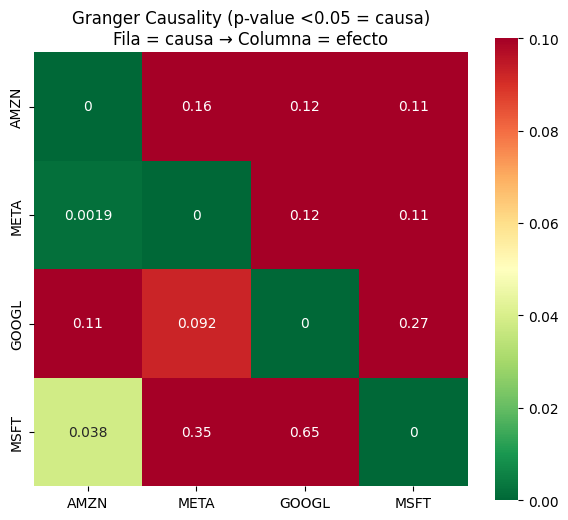

         AMZN    META   GOOGL    MSFT
AMZN   0.0000  0.1611  0.1239  0.1106
META   0.0019  0.0000  0.1159  0.1097
GOOGL  0.1093  0.0922  0.0000  0.2670
MSFT   0.0384  0.3475  0.6513  0.0000


In [92]:
from statsmodels.tsa.stattools import grangercausalitytests

def granger_matrix(data, tickers, maxlag=5, verbose=False):
    """
    data: DataFrame de retornos (returns_log)
    Devuelve matriz con el p-value mínimo entre 1..maxlag
    """
    pval_matrix = pd.DataFrame(index=tickers, columns=tickers, dtype=float)

    for causa in tickers:
        for efecto in tickers:
            if causa == efecto:
                pval_matrix.loc[causa, efecto] = 0.0
                continue

            # statsmodels pide [efecto, causa]
            test_data = data[[efecto, causa]].dropna()

            try:
                res = grangercausalitytests(test_data, maxlag=maxlag, verbose=False)
                # toma el menor p-value de los lags
                p_vals = [res[i+1][0]['ssr_ftest'][1] for i in range(maxlag)]
                pval_matrix.loc[causa, efecto] = round(min(p_vals), 4)
            except:
                pval_matrix.loc[causa, efecto] = np.nan

    return pval_matrix

# USO con tus datos
granger_p = granger_matrix(returns_log, ['AMZN','META','GOOGL','MSFT'], maxlag=5)

plt.figure(figsize=(7,6))
sns.heatmap(granger_p.astype(float), annot=True, cmap='RdYlGn_r',
            vmin=0, vmax=0.1, center=0.05, square=True)
plt.title('Granger Causality (p-value <0.05 = causa)\nFila = causa → Columna = efecto')
plt.show()

print(granger_p)

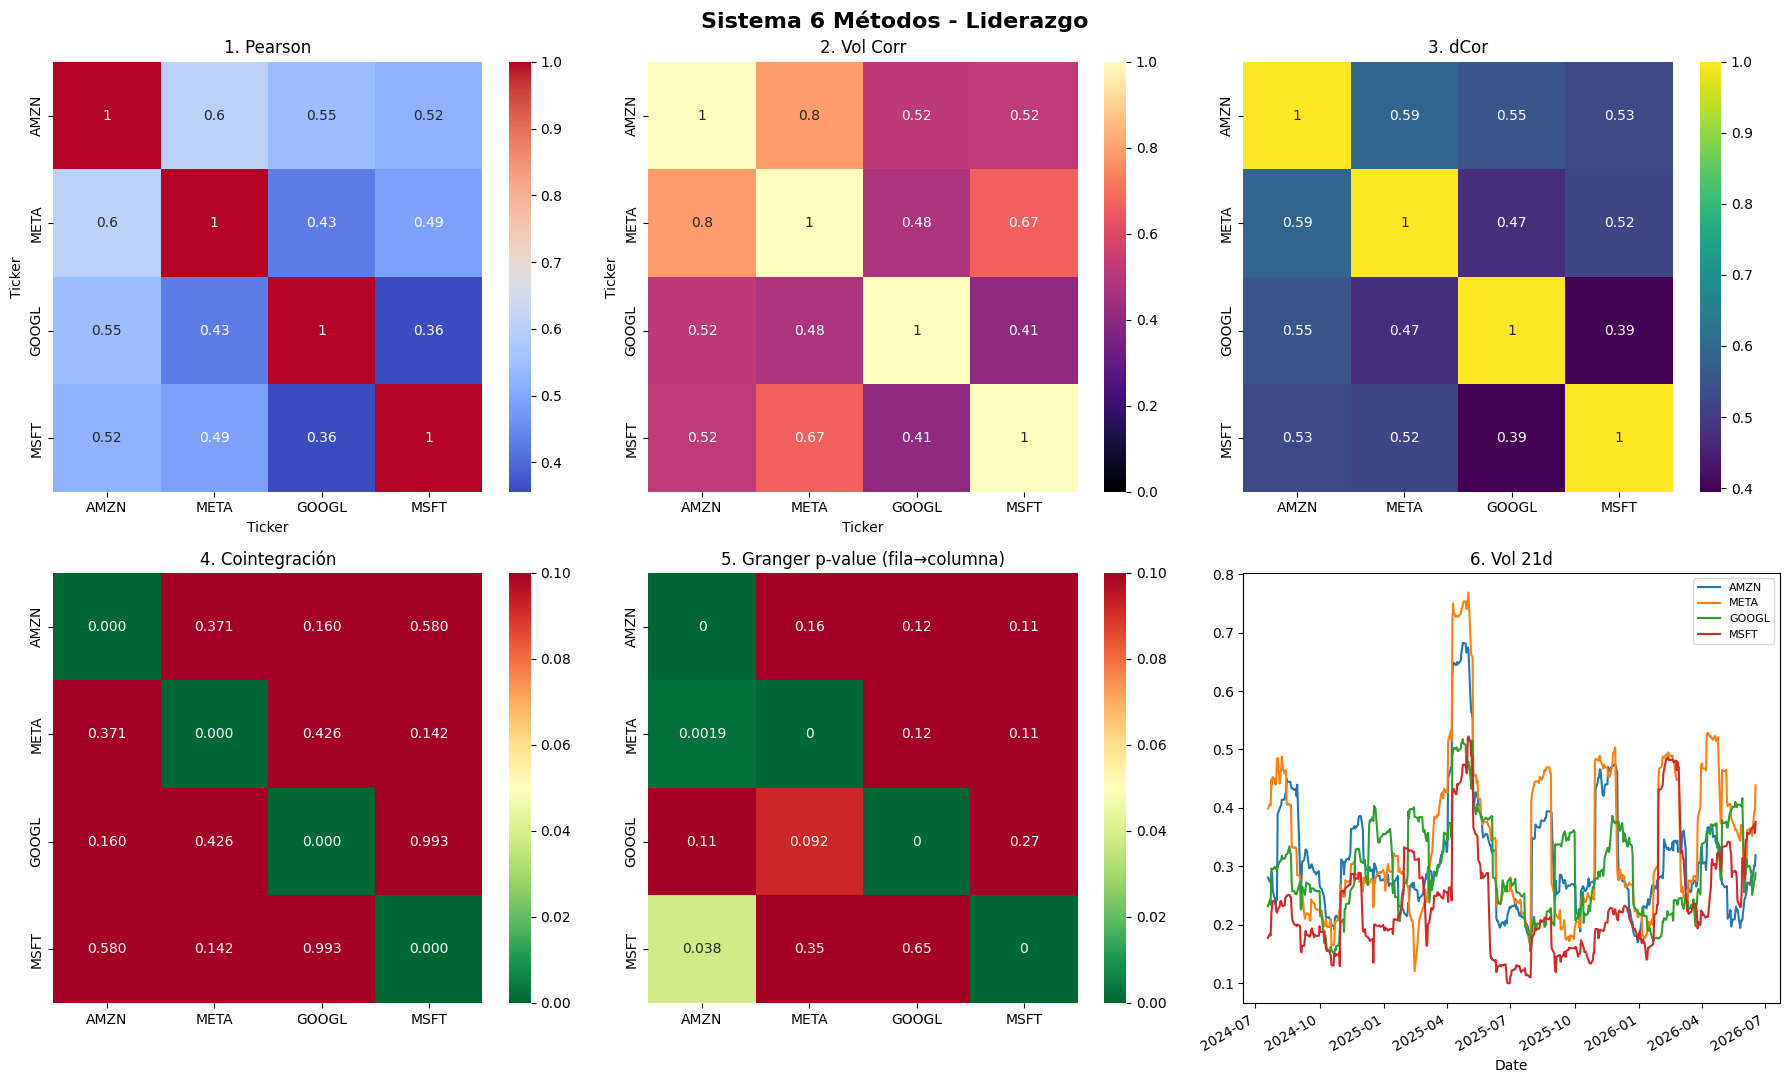


=== TABLA LÍDER → SEGUIDOR ===
Líder Sigue  p-value   Fuerza
 META  AMZN   0.0019   Fuerte
 MSFT  AMZN   0.0384 Moderada


In [ ]:
def reporte_final(prices, returns_log, tickers):

    pearson = returns_log[tickers].corr()
    spearman = returns_log[tickers].corr('spearman')
    dcor_m = pd.DataFrame([[1 if i==j else dcor.distance_correlation(returns_log[i], returns_log[j])
                           for j in tickers] for i in tickers], index=tickers, columns=tickers)
    vol = returns_log[tickers].rolling(21).std()*np.sqrt(252)
    vol_corr = vol.corr()

    # cointegración
    coint_p = pd.DataFrame(1.0, index=tickers, columns=tickers)
    for i,a in enumerate(tickers):
        for j,b in enumerate(tickers):
            if i<j:
                y0,y1 = prices[a].dropna().align(prices[b].dropna(), join='inner')
                _,p,_ = coint(y0,y1); coint_p.loc[a,b]=coint_p.loc[b,a]=p
    np.fill_diagonal = lambda x: [x.iloc[i,i].__setitem__(0,0) for i in range(len(x))] # hack rápido
    for i in range(len(coint_p)): coint_p.iloc[i,i]=0

    # --- 6. GRANGER ---
    granger_p = pd.DataFrame(index=tickers, columns=tickers, dtype=float)
    for causa in tickers:
        for efecto in tickers:
            if causa==efecto: granger_p.loc[causa,efecto]=0; continue
            test = grangercausalitytests(returns_log[[efecto,causa]].dropna(), maxlag=5, verbose=False)
            granger_p.loc[causa,efecto] = min([test[l][0]['ssr_ftest'][1] for l in range(1,6)])

    # tabla líder-seguidor
    lideres = []
    for causa in tickers:
        for efecto in tickers:
            if causa!=efecto and granger_p.loc[causa,efecto] < 0.05:
                lideres.append({'Líder':causa, 'Sigue':efecto,
                               'p-value':round(granger_p.loc[causa,efecto],4),
                               'Fuerza':'Fuerte' if granger_p.loc[causa,efecto]<0.01 else 'Moderada'})
    lider_df = pd.DataFrame(lideres).sort_values('p-value')

    # --- PLOT ---
    fig, ax = plt.subplots(2,3, figsize=(18,11))
    ax=ax.flatten()
    sns.heatmap(pearson, annot=True, cmap='coolwarm', ax=ax[0]); ax[0].set_title('1. Pearson')
    sns.heatmap(vol_corr, annot=True, cmap='magma', vmin=0, vmax=1, ax=ax[1]); ax[1].set_title('2. Vol Corr')
    sns.heatmap(dcor_m, annot=True, cmap='viridis', ax=ax[2]); ax[2].set_title('3. dCor')
    sns.heatmap(coint_p, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0, vmax=0.1, ax=ax[3]); ax[3].set_title('4. Cointegración')
    sns.heatmap(granger_p.astype(float), annot=True, cmap='RdYlGn_r', vmin=0, vmax=0.1, ax=ax[4])
    ax[4].set_title('5. Granger p-value (fila→columna)')
    vol.plot(ax=ax[5]); ax[5].set_title('6. Vol 21d'); ax[5].legend(fontsize=8)
    plt.suptitle('Sistema 6 Métodos - Liderazgo', fontsize=16, fontweight='bold')
    plt.tight_layout(); plt.show()

    return lider_df, granger_p

lider_df, gmat = reporte_final(close_data, returns_log, ['AMZN','META','GOOGL','MSFT'])
print("\n=== TABLA LÍDER → SEGUIDOR ===")
print(lider_df.to_string(index=False))

####################################################################
## **MÉTODO 6: Cross-correlation**
####################################################################

Método 6. Cross-correlation es el primo directo de Granger, pero más visual: te dice con cuántos días de retraso se parecen más dos acciones.

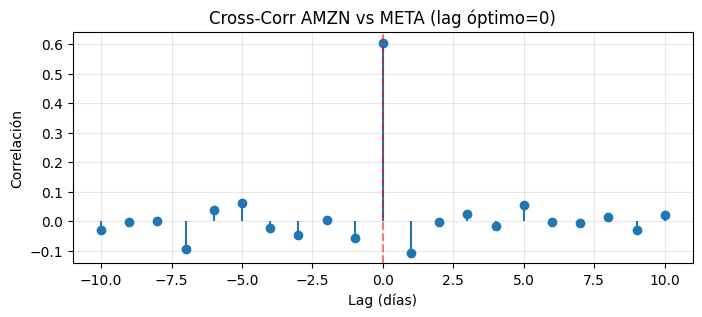

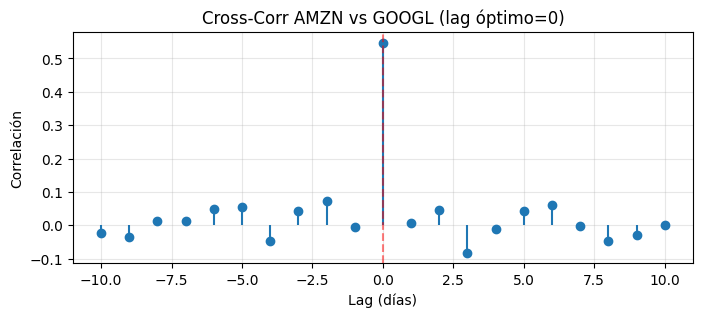

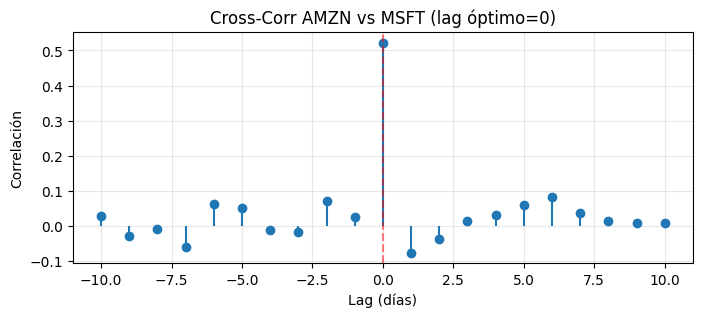

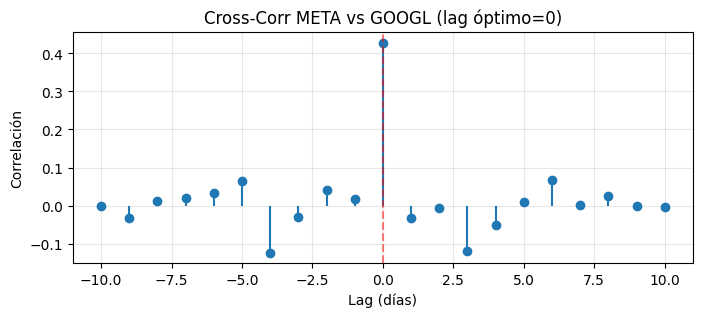

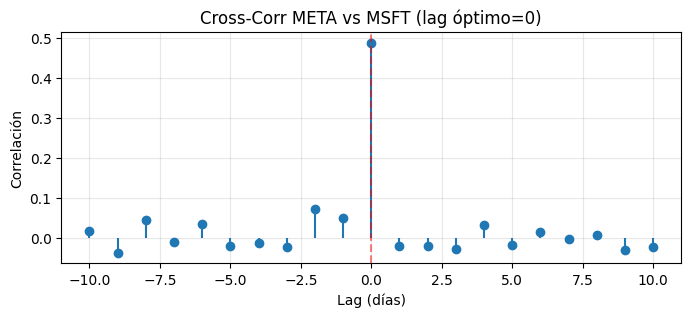

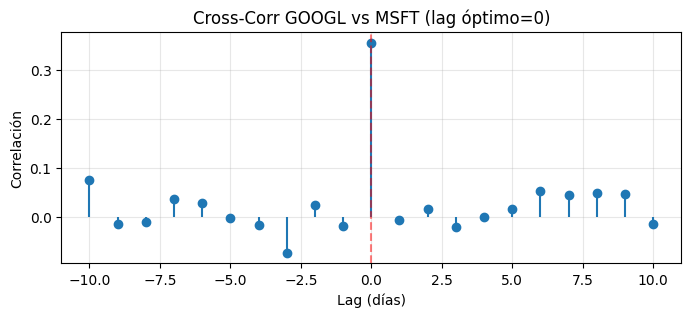

          Par  Mejor_lag  Corr_max  Interpreta
0   AMZN-META          0     0.605  sincrónico
1  AMZN-GOOGL          0     0.547  sincrónico
2   AMZN-MSFT          0     0.522  sincrónico
3  META-GOOGL          0     0.428  sincrónico
4   META-MSFT          0     0.489  sincrónico
5  GOOGL-MSFT          0     0.356  sincrónico


In [98]:
def cross_correlation_matrix(data, tickers, max_lag=20):
    """
    data: returns_log
    Devuelve: mejor lag y correlación para cada par
    lag positivo = fila adelanta a columna
    """
    results = []
    for i, a in enumerate(tickers):
        for j, b in enumerate(tickers):
            if i >= j: continue

            x = data[a].dropna().values
            y = data[b].dropna().values
            # normalizar
            x = (x - x.mean())/x.std()
            y = (y - y.mean())/y.std()

            corr = signal.correlate(x, y, mode='full')
            lags = signal.correlation_lags(len(x), len(y), mode='full')
            # limitar a max_lag
            mask = (lags >= -max_lag) & (lags <= max_lag)
            corr, lags = corr[mask], lags[mask]
            corr = corr / len(x) # normalizar

            best_idx = np.argmax(np.abs(corr))
            best_lag = lags[best_idx]
            best_corr = corr[best_idx]

            results.append({
                'Par': f'{a}-{b}',
                'Mejor_lag': int(best_lag),
                'Corr_max': round(best_corr,3),
                'Interpreta': f'{a} adelanta {abs(best_lag)}d' if best_lag>0 else
                              f'{b} adelanta {abs(best_lag)}d' if best_lag<0 else 'sincrónico'
            })

            # plot individual
            plt.figure(figsize=(8,3))
            plt.stem(lags, corr, basefmt=" ")
            plt.axvline(0, color='red', linestyle='--', alpha=0.5)
            plt.title(f'Cross-Corr {a} vs {b} (lag óptimo={best_lag})')
            plt.xlabel('Lag (días)'); plt.ylabel('Correlación')
            plt.grid(alpha=0.3); plt.show()

    return pd.DataFrame(results)

# USO
cc_df = cross_correlation_matrix(returns_log, ['AMZN','META','GOOGL','MSFT'], max_lag=10)
print(cc_df)

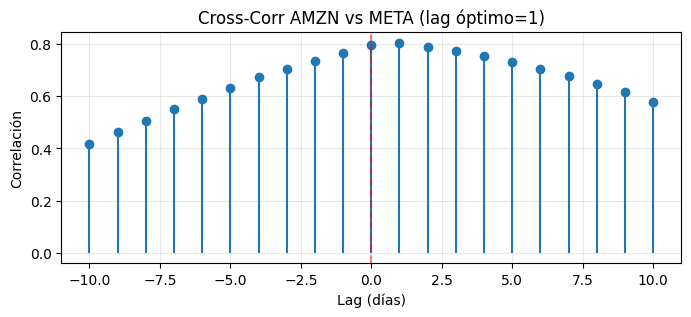

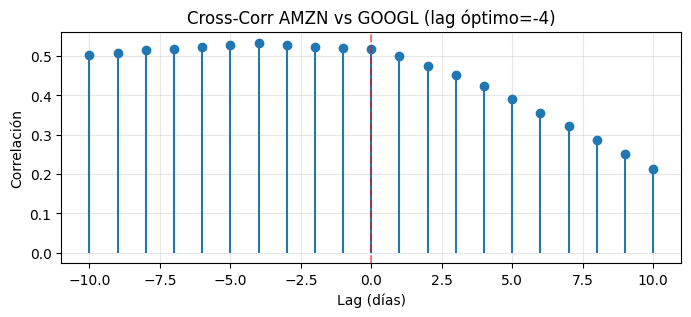

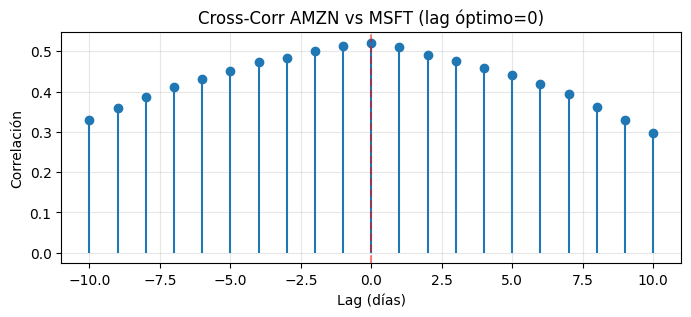

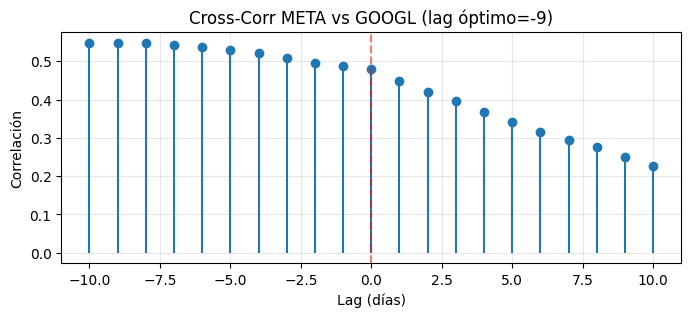

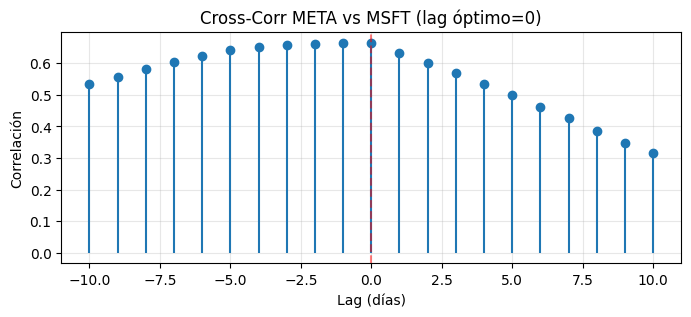

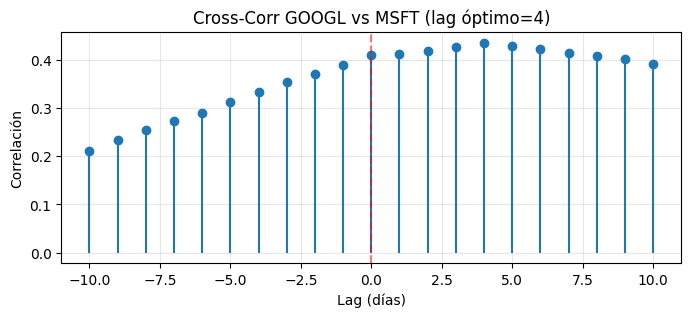

          Par  Mejor_lag  Corr_max         Interpreta
0   AMZN-META          1     0.805   AMZN adelanta 1d
1  AMZN-GOOGL         -4     0.534  GOOGL adelanta 4d
2   AMZN-MSFT          0     0.521         sincrónico
3  META-GOOGL         -9     0.549  GOOGL adelanta 9d
4   META-MSFT          0     0.665         sincrónico
5  GOOGL-MSFT          4     0.435  GOOGL adelanta 4d


In [101]:
vol = returns_log[tickers].rolling(21).std()*np.sqrt(252)
cc_vol = cross_correlation_matrix(vol, ['AMZN','META','GOOGL','MSFT'], max_lag=10)
print(cc_vol)

Resumen de la tabla de cross-correlation sobre la volatilidad 21d:

    * AMZN-META: lag +1, corr 0.805 → La volatilidad de AMZN se adelanta 1 día a la de META con 80% de correlación. Es casi perfecto.
    * META-MSFT: lag 0, corr 0.665 → se estresan juntos, sincrónico.
    * GOOGL adelanta a todos: 4 días a AMZN, 9 días a META, 4 días a MSFT. GOOGL es el "canario en la mina" de volatilidad.

Esto es lo contrario a lo que vimos en retornos:

    * En retornos, Granger decía META → AMZN (p=0.0019)
    * En volatilidad, Cross-corr dice AMZN → META (1 día, 0.805)

Traducción práctica:

    * META mueve el precio de AMZN, pero AMZN avisa primero cuando viene el miedo.
    * GOOGL no mueve precios (Granger p>0.09), pero su volatilidad es la primera en despertar. Si ves vol de GOOGL subir, en 4-9 días sube la del resto.
    * AMZN-MSFT y META-MSFT son sincrónicos en vol (lag 0) → cuando hay pánico, explotan juntos.

####################################################################
## **MÉTODO 7: MUTUAL INFORMATION**
####################################################################

* Mutual Information (MI) no asume linealidad como Pearson, mide cuánta información de un activo te dice sobre otro, aunque la relación sea curva, en forma de U, o por umbrales.

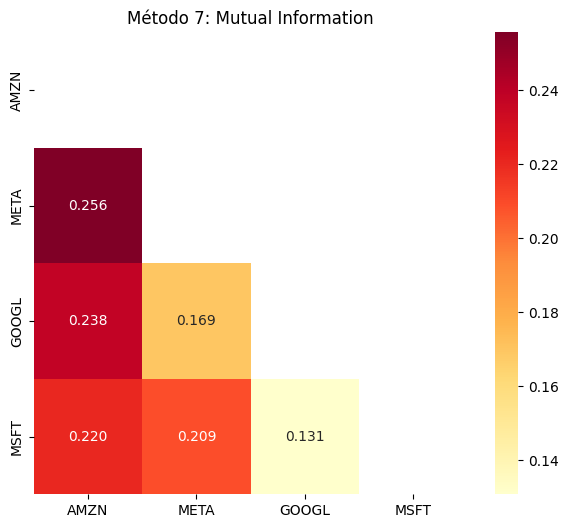

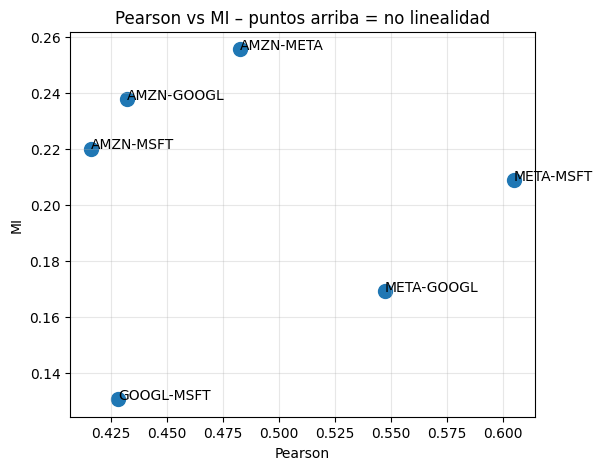

In [102]:
from sklearn.feature_selection import mutual_info_regression
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

def mutual_info_matrix(returns, tickers):
    n = len(tickers)
    mi = np.zeros((n,n))
    for i in range(n):
        for j in range(i+1, n):
            X = returns[tickers[i]].values.reshape(-1,1)
            y = returns[tickers[j]].values
            val = mutual_info_regression(X, y, random_state=42)[0]
            mi[i,j] = mi[j,i] = val
    return pd.DataFrame(mi, index=tickers, columns=tickers)

mi_df = mutual_info_matrix(returns_log, ['AMZN','META','GOOGL','MSFT'])

# heatmap
plt.figure(figsize=(7,6))
mask = np.triu(np.ones_like(mi_df, dtype=bool))
sns.heatmap(mi_df, mask=mask, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('Método 7: Mutual Information')
plt.show()

# comparación con Pearson
pearson = returns_log.corr()
plt.figure(figsize=(6,5))
plt.scatter(pearson.values[np.triu_indices(4,1)], mi_df.values[np.triu_indices(4,1)], s=100)
for (i,j),x,y in zip([(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)],
                     pearson.values[np.triu_indices(4,1)],
                     mi_df.values[np.triu_indices(4,1)]):
    plt.text(x,y, f"{['AMZN','META','GOOGL','MSFT'][i]}-{['AMZN','META','GOOGL','MSFT'][j]}")
plt.xlabel('Pearson'); plt.ylabel('MI'); plt.grid(alpha=0.3)
plt.title('Pearson vs MI – puntos arriba = no linealidad')
plt.show()

Pearson vs MI (el gráfico de la derecha):

* META-MSFT está a la derecha (Pearson 0.605) pero MI solo 0.209 → su relación es casi 100% lineal, no hay sorpresa no lineal.
* AMZN-META, AMZN-GOOGL, AMZN-MSFT están arriba a la izquierda → tienen MI alto con Pearson medio (0.42-0.48). Eso es la firma de no linealidad: comparten más información de la que Pearson puede explicar.
* GOOGL-MSFT abajo a la izquierda → poca correlación y poca información mutua. Confirmado por tercera vez.